# Circadian cycles Analysis first week of crisis

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import powerlaw, truncnorm, ks_2samp
import powerlaw
import random

# Simple trapezoid integration for NumPy 2.0+ compatibility
def trapz(y, x):
    return np.sum((x[1:] - x[:-1]) * (y[1:] + y[:-1]) / 2)


In [35]:
# import datasets
df = pd.read_json("../../Datasets/voluntariosdanavalencia_old.json") # Import data from Voluntarios de Valencia groupchat.
df_links = pd.read_csv("../../Datasets/voluntariosdanavalencia_extracted_links.csv") # Import data from Voluntarios de Valencia groupchat with messages with links and misinformation score.
df_users = pd.read_csv("../../Datasets/voluntariosdanavalencia_extracted_users.csv") # Import data from Voluntarios de Valencia groupchat with user information.

## Prepare data

In [36]:
def normalize_data(df):
    df["id"]= pd.to_numeric(df["id"], errors='coerce').astype('Int64')   # Convert 'id' to numeric, coercing errors to NaN.
    df["sender_id"]= pd.to_numeric(df["sender_id"], errors='coerce').astype('Int64')   # Convert 'sender_id' to numeric, coercing errors to NaN.
    df["date"]= pd.to_datetime(df["date"], errors='coerce')   # Convert 'date' to datetime, coercing errors to NaT.
    df["edit_date"]= pd.to_datetime(df["edit_date"], errors='coerce')   # Convert 'edit_date' to datetime, coercing errors to NaT.
    df["reply_to_msg_id"]= pd.to_numeric(df["reply_to_msg_id"], errors='coerce').astype('Int64')   # Convert 'reply_to_message_id' to numeric, coercing errors to NaN.
    df["views"]= pd.to_numeric(df["views"], errors='coerce').astype('Int64')   # Convert 'views' to numeric, coercing errors to NaN.
    df["forwards"]= pd.to_numeric(df["forwards"], errors='coerce').astype('Int64')   # Convert 'forwards' to numeric, coercing errors to NaN.
    return df
df = normalize_data(df) # Normalize the data types of the DataFrame columns.

In [37]:
# Keep only messages until 2024-11-04 to analyze the first week of the groupchat.
df_first_week = df[df["date"] < "2024-11-04"]


In [38]:
# Gather users with more than 40 messages in the first week of the groupchat.
user_message_counts = df_first_week['sender_id'].value_counts()
active_users = user_message_counts[user_message_counts > 40].index.tolist()
active_users_message_counts = user_message_counts[user_message_counts > 40]
# Print the number of active users.
print(f"Number of active users (more than 40 messages in the first week): {len(active_users)}")


Number of active users (more than 40 messages in the first week): 31


In [39]:
df_first_week = df_first_week.sort_values('date') # Sort messages by date to calculate inter-event times correctly.

# Calcular inter-event times en segundos
df_first_week['iet'] = df_first_week['date'].diff().dt.total_seconds()



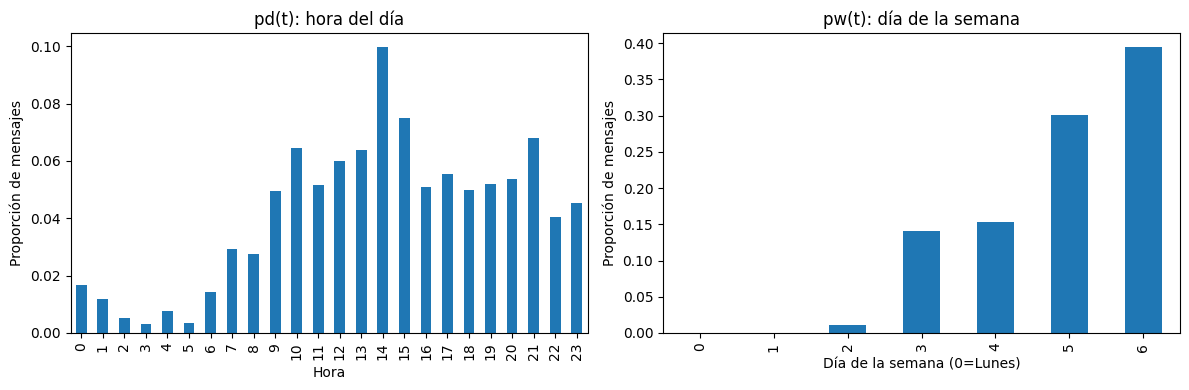

In [40]:
df_first_week['hour'] = df_first_week['date'].dt.hour
df_first_week['weekday'] = df_first_week['date'].dt.weekday  # 0=lunes

if df_first_week.empty:
    print("df_first_week está vacío: no hay datos para la primera semana. Revisa el filtrado de fechas.")
else:
    # pd(t): distribución por hora del día (aseguramos horas 0-23)
    hours = list(range(24))
    pd_t_counts = df_first_week.groupby('hour').size()
    pd_t = pd_t_counts.reindex(hours, fill_value=0) / len(df_first_week)

    # pw(t): distribución por día de la semana (aseguramos días 0-6)
    days = list(range(7))
    pw_t_counts = df_first_week.groupby('weekday').size()
    pw_t = pw_t_counts.reindex(days, fill_value=0) / len(df_first_week)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    pd_t.plot(kind='bar', ax=axes[0], title='pd(t): hora del día')
    pw_t.plot(kind='bar', ax=axes[1], title='pw(t): día de la semana')
    axes[0].set_xlabel('Hora')
    axes[0].set_ylabel('Proporción de mensajes')
    axes[1].set_xlabel('Día de la semana (0=Lunes)')
    axes[1].set_ylabel('Proporción de mensajes')
    plt.tight_layout()
    plt.show()

## Active intervals identification (Annealing)

In [41]:
def compute_model_params(events, active_config):
    """
    events: array de tiempos en HORAS.
    active_config: bool array N. True = mismo AI que el evento anterior.
    """
    iets = np.diff(events)
    iet_active = iets[active_config[1:]]
    rho_a = 1.0 / np.mean(iet_active) if len(iet_active) > 0 else 0

    n_active_intervals = np.sum(~active_config[1:]) + 1
    total_weeks = (events[-1] - events[0]) / (7 * 24)
    Nw = n_active_intervals / total_weeks if total_weeks > 0 else 0

    starts_idx = np.where(~active_config[1:])[0] + 1
    start_times = np.concatenate([events[:1], events[starts_idx]])
    hours    = start_times % 24
    weekdays = (start_times / 24) % 7

    pd_counts, _ = np.histogram(hours,    bins=24, range=(0, 24))
    pw_counts, _ = np.histogram(weekdays, bins=7,  range=(0, 7))
    pd_t = pd_counts / pd_counts.sum() if pd_counts.sum() > 0 else np.zeros(24)
    pw_t = pw_counts / pw_counts.sum() if pw_counts.sum() > 0 else np.zeros(7)
    return rho_a, Nw, pd_t, pw_t


def get_pNa(config):
    """
    Distribución empírica de Na. config: bool array N-1, True = par (i,i+1) en el mismo AI.
    """
    na_counts, count = [], 0
    for c in config:
        if c:
            count += 1
        else:
            na_counts.append(count)
            count = 0
    na_counts.append(count)
    hist = np.bincount(na_counts)
    return hist / hist.sum()


def init_threshold(iets):
    """
    Calcula el umbral iterativamente: threshold = 0.1/rho_primary = 0.1 * mean_iet * (1+mean_Na).
    """
    pos = iets[iets > 0]
    if len(pos) < 20:
        return np.median(pos)

    mean_iet  = np.mean(pos)
    threshold = 0.1 * mean_iet

    for _ in range(15):
        n_within  = int(np.sum(pos < threshold))
        n_between = int(np.sum(pos >= threshold))
        mean_Na_est   = n_within / max(n_between, 1)
        threshold_new = 0.1 * mean_iet * (1 + mean_Na_est)
        if abs(threshold_new - threshold) < 1e-6 * mean_iet:
            break
        threshold = threshold_new

    return threshold_new


def area_test_statistic(empirical_iet, model_iet, n_bins=100, eps=1e-6):
    emp = np.asarray(empirical_iet)
    mod = np.asarray(model_iet)
    emp = emp[np.isfinite(emp) & (emp > 0)]
    mod = mod[np.isfinite(mod) & (mod > 0)]
    if len(emp) == 0 or len(mod) == 0:
        return np.inf
    lo = max(emp.min(), mod.min(), eps)
    hi = max(emp.max(), mod.max(), lo * 10)
    log_bins = np.logspace(np.log10(lo), np.log10(hi), n_bins)
    ccdf_emp = np.array([np.mean(emp > b) for b in log_bins])
    ccdf_mod = np.array([np.mean(mod > b) for b in log_bins])
    return trapz(np.abs(ccdf_emp - ccdf_mod), np.log(log_bins))


def simulate_cascading_nhpp(rho_a, Nw, pd_t, pw_t, p_Na, total_hours, n_samples=None):
    """
    Simula el cascading NHPP del paper Malmgren et al. (2008).
    Proceso primario: NHPP con tasa rho(t) = Nw * pd(t) * pw(t).
    Proceso secundario: HPP con tasa rho_a dentro de cada active interval.
    """
    pd_t_arr = np.asarray(pd_t, dtype=float)
    pw_t_arr = np.asarray(pw_t, dtype=float)
    pd_t_arr = pd_t_arr / pd_t_arr.sum()
    pw_t_arr = pw_t_arr / pw_t_arr.sum()
    p_Na_norm = np.asarray(p_Na, dtype=float)
    p_Na_norm = p_Na_norm / p_Na_norm.sum()

    mean_Na = np.dot(np.arange(len(p_Na_norm)), p_Na_norm)

    # Si n_samples requiere más eventos de los naturales, extender la ventana temporal
    sim_hours = total_hours
    if n_samples is not None and Nw > 0:
        expected_events = Nw * (total_hours / (7 * 24)) * (1 + mean_Na)
        if expected_events < n_samples:
            sim_hours = total_hours * (n_samples / max(1, expected_events)) * 1.5

    n_weeks = sim_hours / (7 * 24)

    # Distribución conjunta (día, hora): outer product pw_t x pd_t → 168 slots semanales
    joint = np.outer(pw_t_arr, pd_t_arr).flatten()  # shape (7*24,)
    joint /= joint.sum()

    n_bursts = np.random.poisson(max(1.0, Nw * n_weeks))

    # Muestrear semana (uniforme en [0, n_weeks)) y slot (día, hora) de la distribución conjunta
    week_nums = np.random.uniform(0, n_weeks, n_bursts)
    slots = np.random.choice(168, size=n_bursts, p=joint)

    # Convertir a horas absolutas: inicio_semana + día*24 + hora + ruido uniforme
    burst_times = (
        np.floor(week_nums) * 7 * 24        # inicio de la semana entera
        + (slots // 24) * 24                # offset del día (0–6 × 24 h)
        + (slots % 24)                      # offset de la hora (0–23 h)
        + np.random.uniform(0, 1, n_bursts) # ruido uniforme dentro de la hora
    )
    burst_times = np.sort(burst_times)
    burst_times = burst_times[burst_times < sim_hours]

    if rho_a <= 0:
        rho_a = 1.0

    # Generar cascadas: inicio de ráfaga + Na eventos adicionales a tasa rho_a
    events = []
    for bt in burst_times:
        events.append(bt)
        Na = np.random.choice(len(p_Na_norm), p=p_Na_norm)
        t = bt
        for _ in range(Na):
            t += np.random.exponential(1.0 / rho_a)
            events.append(t)

    # IMPORTANTE: ordenar — dos cascadas consecutivas pueden solaparse en tiempo,
    # produciendo IETs negativos si no se ordena antes de np.diff()
    result = np.sort(np.array(events))

    if n_samples is not None:
        return result[:n_samples]
    return result


def simulated_annealing(events_hours, n_iter=5000, T_init=1.0, cooling=0.95, n_sim=None):
    """
    Simulated Annealing para identificar active intervals (Malmgren et al. 2008, SI).

    Correcciones respecto al código original:
      (1) pd_t y pw_t se fijan antes del SA y no se recalculan (SI Simplification #2).
      (2) Solo se proponen flips para pares con τ < threshold (SI Simplification #3).
      (3) cool_every = n_iter // 50 garantiza ~50 pasos de enfriamiento.
    """
    N    = len(events_hours)
    iets = np.diff(events_hours)
    if n_sim is None:
        n_sim = max(5000, 10 * N)

    # Corrección #1: fijar pd_t y pw_t de la distribución empírica ANTES del SA
    all_hours    = events_hours % 24
    all_weekdays = (events_hours / 24) % 7
    pd_counts, _ = np.histogram(all_hours,    bins=24, range=(0, 24))
    pw_counts, _ = np.histogram(all_weekdays, bins=7,  range=(0, 7))
    pd_t_fixed = pd_counts / pd_counts.sum() if pd_counts.sum() > 0 else np.ones(24) / 24
    pw_t_fixed = pw_counts / pw_counts.sum() if pw_counts.sum() > 0 else np.ones(7) / 7

    def compute_area(cfg):
        rho_a, Nw, _, _ = compute_model_params(
            events_hours, np.concatenate([[False], cfg])
        )
        p_Na = get_pNa(cfg)
        model_events = simulate_cascading_nhpp(
            rho_a, Nw, pd_t_fixed, pw_t_fixed, p_Na,
            total_hours=events_hours[-1] - events_hours[0],
            n_samples=n_sim
        )
        if len(model_events) > 1:
            return area_test_statistic(iets, np.diff(model_events))
        return np.inf

    threshold = init_threshold(iets)
    config    = iets < threshold

    # Corrección #2: solo proponer flips para pares con τ < threshold
    mergeable = np.where(iets < threshold)[0]
    if len(mergeable) == 0:
        mergeable = np.arange(N - 1)

    print(f"  Init: {config.mean():.1%} pares mergeados  "
          f"(threshold={threshold:.4f}h = {threshold*60:.1f}min, "
          f"candidatos={len(mergeable)}/{N-1})")

    T           = T_init
    best_config = config.copy()
    A_current   = compute_area(config)
    A_best      = A_current

    # Corrección #3: ~50 pasos de enfriamiento garantizados en n_iter iteraciones
    cool_every = max(1, n_iter // 50)

    for iteration in range(n_iter):
        idx        = mergeable[random.randint(0, len(mergeable) - 1)]
        new_config = config.copy()
        new_config[idx] = not new_config[idx]

        A_new = compute_area(new_config)
        delta = A_new - A_current
        if delta < 0 or random.random() < np.exp(-delta / T):
            config    = new_config
            A_current = A_new
            if A_new < A_best:
                A_best      = A_new
                best_config = new_config.copy()

        if (iteration + 1) % cool_every == 0:
            T *= cooling

    return best_config, A_best


In [42]:
# Guardar parámetros por usuario
parameters_users = {}
i=0
for user_id in active_users:
    print(f"Procesando usuario {user_id}... ({i+1}/{len(active_users)})")
    i += 1
    user_events = df_first_week[df_first_week['sender_id'] == user_id]['date'].sort_values()
    if len(user_events) < 2:
        continue

    events_hours = (user_events - user_events.iloc[0]).dt.total_seconds() / 3600

    best_config, A_best = simulated_annealing(events_hours.values)

    rho_a, Nw, pd_t, pw_t = compute_model_params(
        events_hours.values,
        np.concatenate([[False], best_config])
    )
    p_Na = get_pNa(best_config)  # distribución empírica de Na (estimada por SA)

    parameters_users[user_id] = {
        'rho_a': rho_a,
        'Nw': Nw,
        'pd_t': pd_t,
        'pw_t': pw_t,
        'p_Na': p_Na,   # guardada para el test MC
        'A_best': A_best
    }


Procesando usuario 1095473116... (1/31)
  Init: 91.5% pares mergeados  (threshold=0.1950h = 11.7min, candidatos=204/223)
Procesando usuario 1762777403... (2/31)
  Init: 64.5% pares mergeados  (threshold=0.0705h = 4.2min, candidatos=136/211)
Procesando usuario 1457424889... (3/31)
  Init: 99.0% pares mergeados  (threshold=0.4836h = 29.0min, candidatos=205/207)
Procesando usuario 7094531229... (4/31)
  Init: 78.4% pares mergeados  (threshold=0.1296h = 7.8min, candidatos=152/194)
Procesando usuario 702737014... (5/31)
  Init: 64.5% pares mergeados  (threshold=0.1077h = 6.5min, candidatos=91/141)
Procesando usuario 57072401... (6/31)
  Init: 84.0% pares mergeados  (threshold=0.1320h = 7.9min, candidatos=110/131)
Procesando usuario 1110241832... (7/31)
  Init: 70.8% pares mergeados  (threshold=0.3041h = 18.2min, candidatos=85/120)
Procesando usuario 5212333848... (8/31)
  Init: 76.0% pares mergeados  (threshold=0.2216h = 13.3min, candidatos=79/104)
Procesando usuario 1065332141... (9/31)
  

In [43]:
print("Parámetros estimados para usuarios activos:")
for user_id, params in parameters_users.items():
    print(f"Usuario {user_id}: rho_a={params['rho_a']:.4f}, Nw={params['Nw']:.4f}, A_best={params['A_best']:.4f}, pd_t={params['pd_t']}, pw_t={params['pw_t']}")

Parámetros estimados para usuarios activos:
Usuario 1095473116: rho_a=32.4223, Nw=99.7578, A_best=1.0491, pd_t=[0.18181818 0.04545455 0.04545455 0.         0.04545455 0.04545455
 0.09090909 0.04545455 0.09090909 0.18181818 0.09090909 0.04545455
 0.         0.04545455 0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.04545455], pw_t=[0.63636364 0.36363636 0.         0.         0.         0.
 0.        ]
Usuario 1762777403: rho_a=42.8070, Nw=479.4632, A_best=0.6594, pd_t=[0.08609272 0.08609272 0.09271523 0.04635762 0.02649007 0.02649007
 0.00662252 0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.07284768 0.12582781
 0.09271523 0.05960265 0.11258278 0.05298013 0.0397351  0.07284768], pw_t=[0.33112583 0.60927152 0.05960265 0.         0.         0.
 0.        ]
Usuario 1457424889: rho_a=108.9460, Nw=52.1065, A_best=1.6789, pd_t=[0.33333333 0.33333333 0.         0.         0.         0.
 0.         0.  

In [44]:
# Simular cascadas para cada usuario con los parámetros estimados por SA
simulated_cascades = {}
for user_id, params in parameters_users.items():
    user_events = df_first_week[df_first_week['sender_id'] == user_id]['date'].sort_values()
    total_hours = (user_events.iloc[-1] - user_events.iloc[0]).total_seconds() / 3600
    n_events = len(user_events)

    sim_events = simulate_cascading_nhpp(
        params['rho_a'], params['Nw'], params['pd_t'], params['pw_t'],
        p_Na=params['p_Na'],      # distribución empírica estimada por SA
        total_hours=total_hours,
        n_samples=n_events
    )
    simulated_cascades[user_id] = sim_events


In [45]:
# Fit all users' IETs to power-law with exponential cutoff: P(x) ∝ x^(-alpha) * exp(-lambda*x)
from scipy.optimize import minimize

def fit_power_law_with_cutoff(iets):
    """
    Fit data to power-law with exponential cutoff using MLE.
    Returns (alpha, lambda) where P(x) ∝ x^(-alpha) * exp(-lambda*x)
    """
    if len(iets) < 2:
        return None, None
    
    iets = np.asarray(iets)
    iets = iets[iets > 0]  # Remove non-positive values
    if len(iets) < 2:
        return None, None
    
    # Negative log-likelihood for power-law with exponential cutoff
    def neg_loglik(params):
        alpha, lam = params
        if alpha <= 0 or lam <= 0:
            return 1e10
        # log P(x) = -alpha*log(x) - lambda*x + const
        return np.sum(alpha * np.log(iets) + lam * iets)
    
    # Initial guess: alpha from simple power-law, lambda small
    alpha_init = 2.0
    lam_init = 0.01
    
    # Optimize
    result = minimize(neg_loglik, [alpha_init, lam_init], 
                     method='Nelder-Mead',
                     options={'maxiter': 1000})
    
    if result.success:
        alpha, lam = result.x
        return float(alpha), float(lam)
    else:
        return None, None

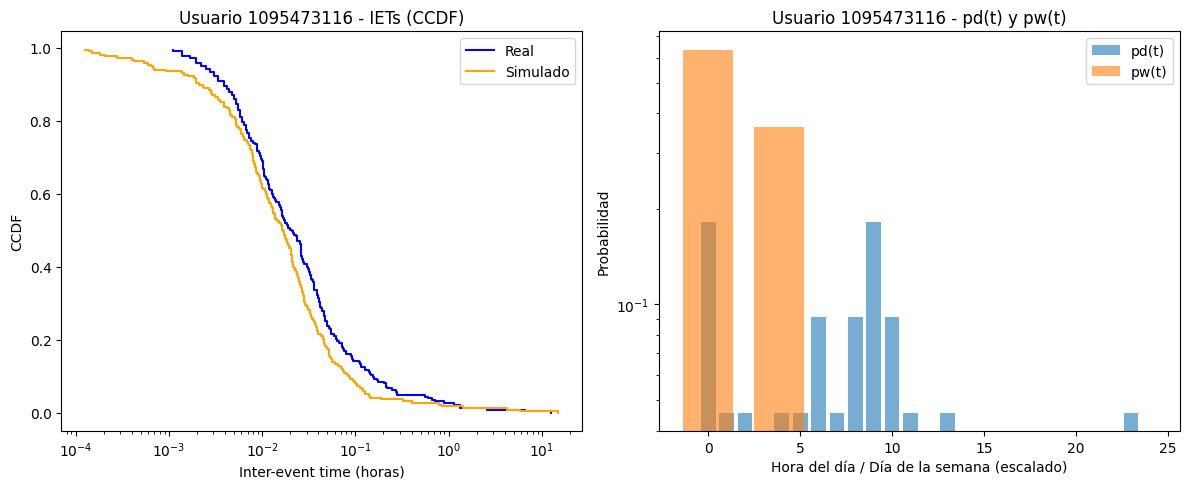

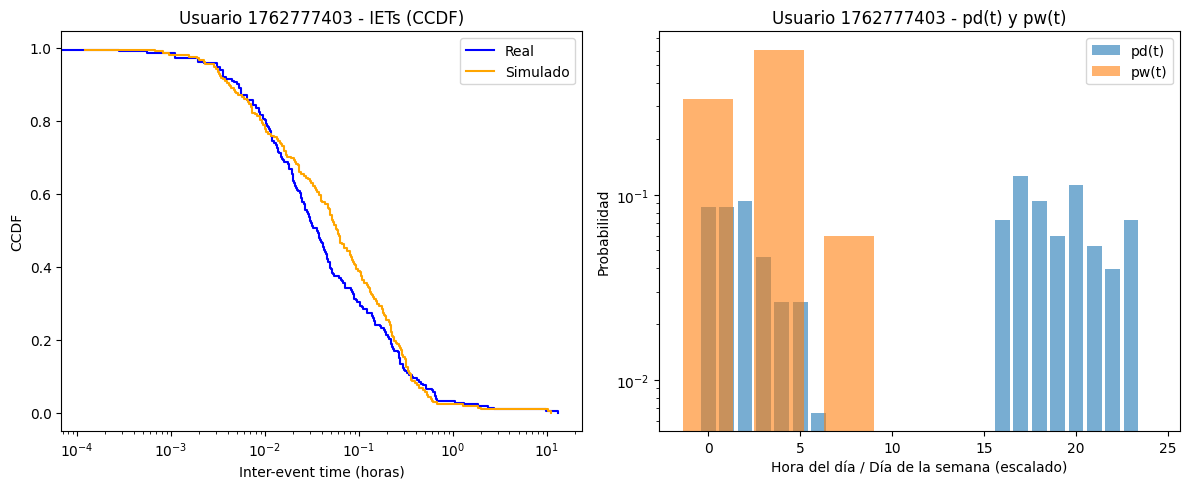

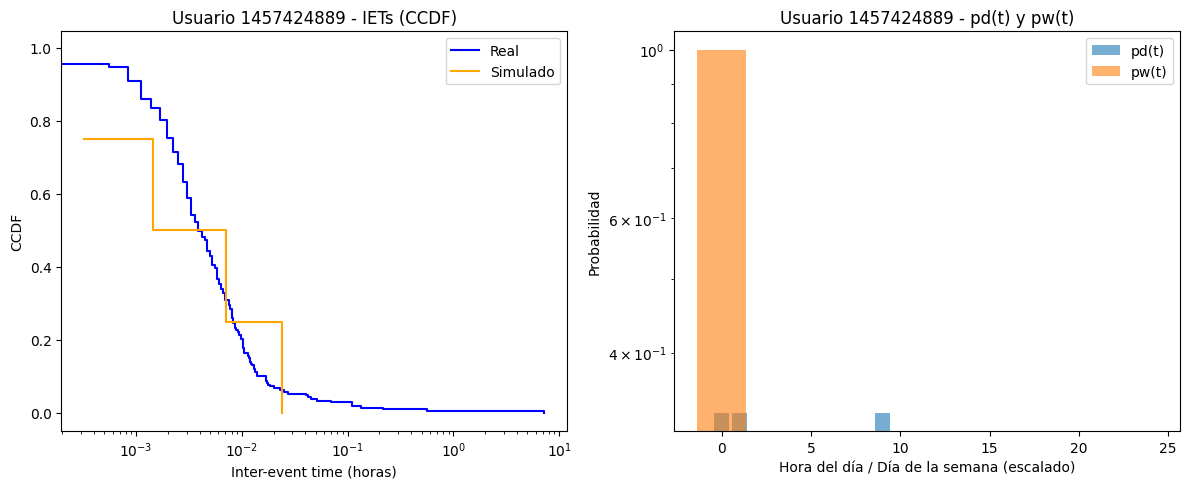

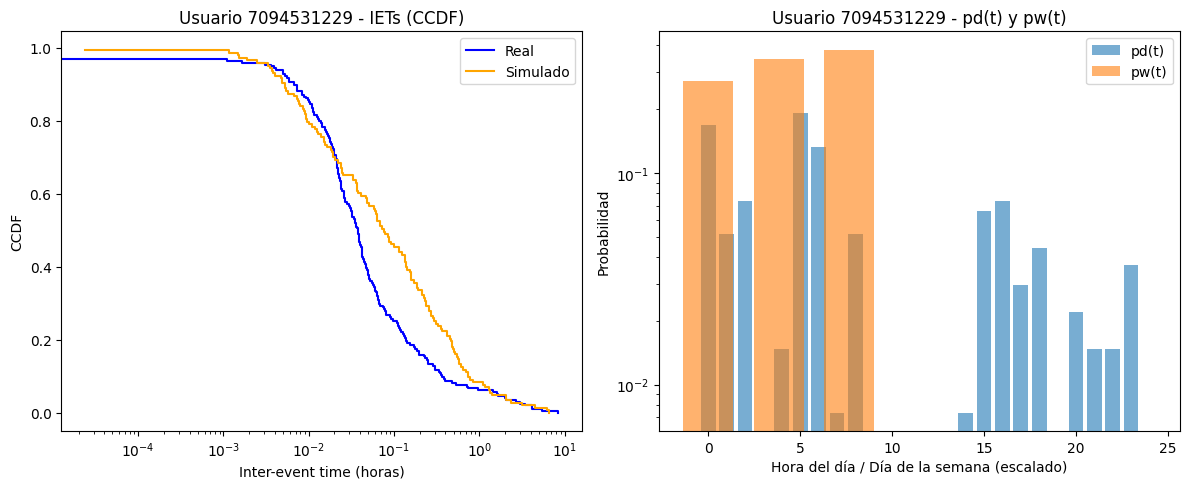

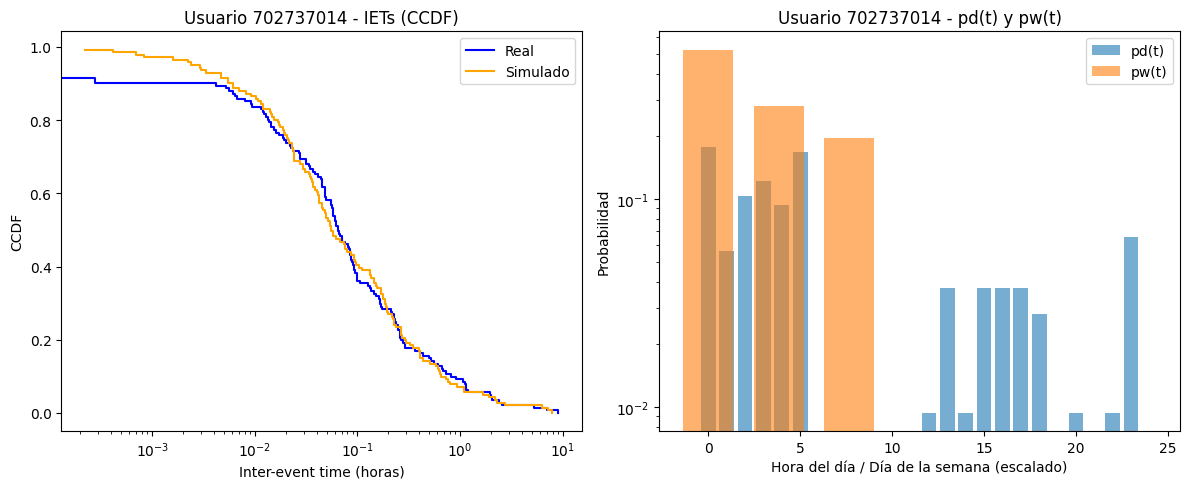

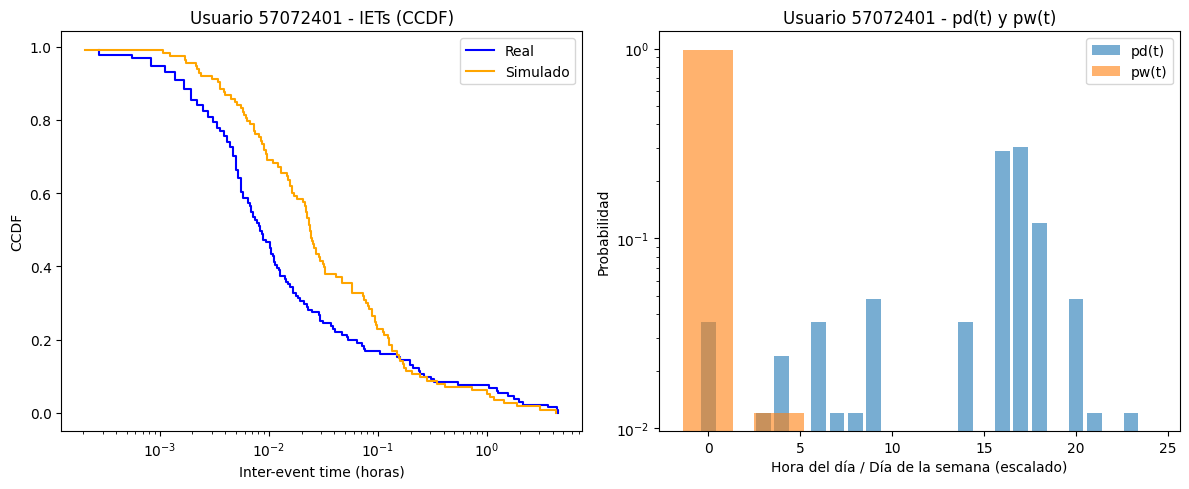

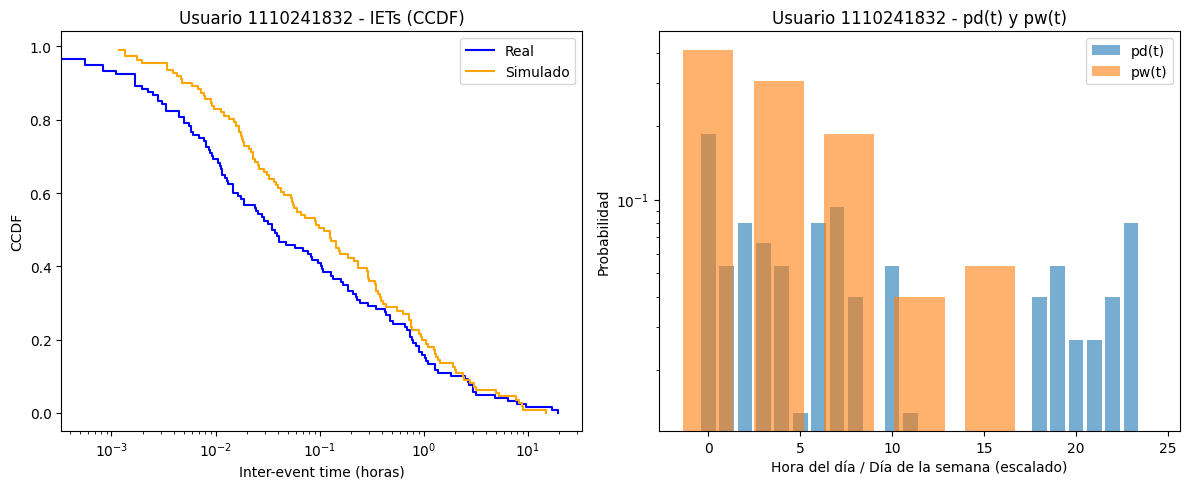

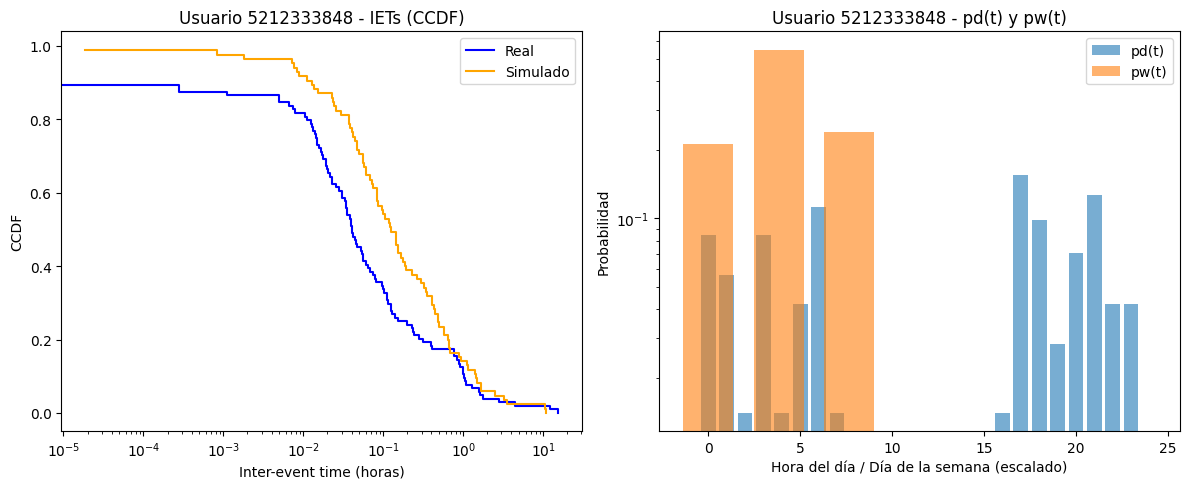

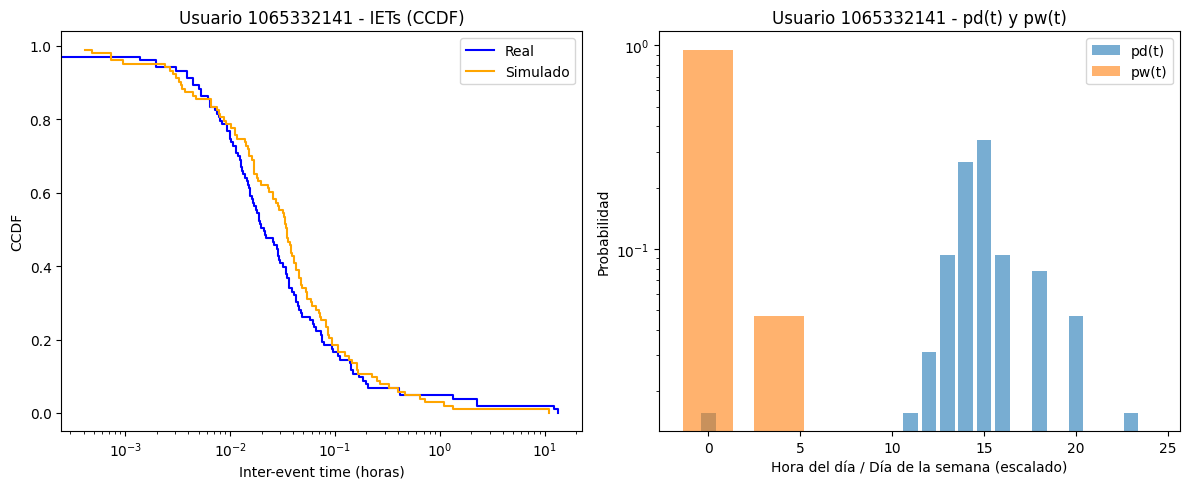

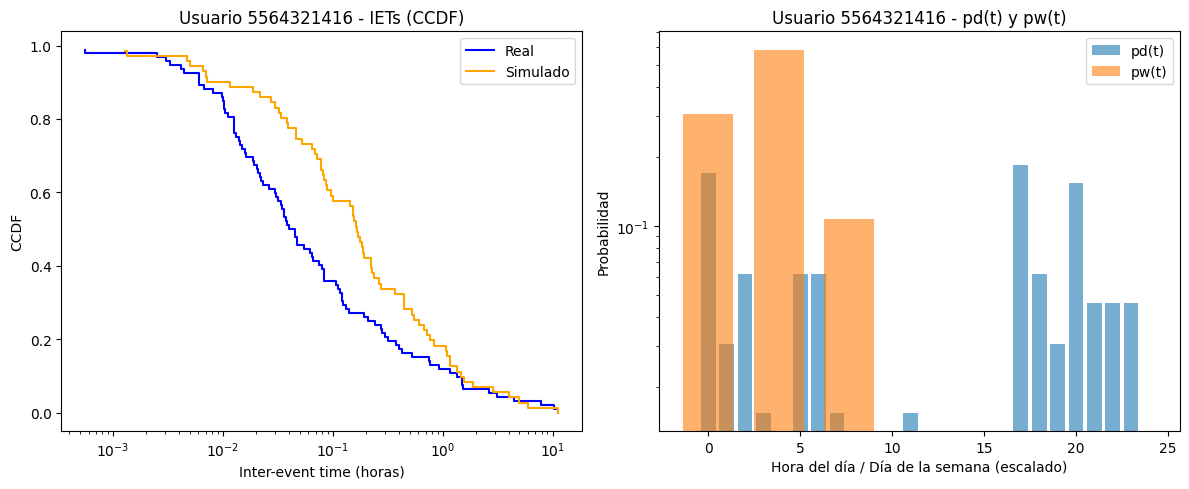

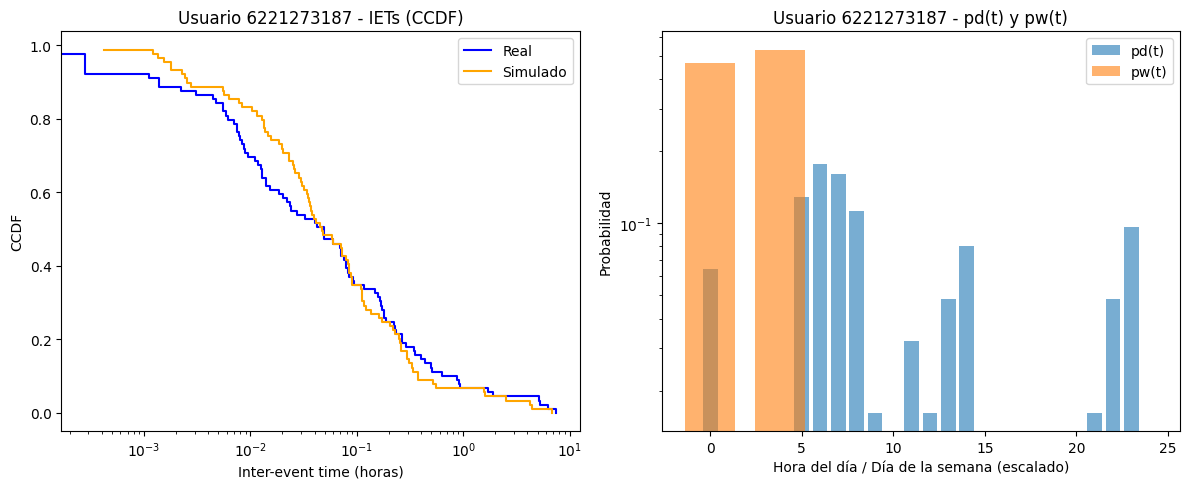

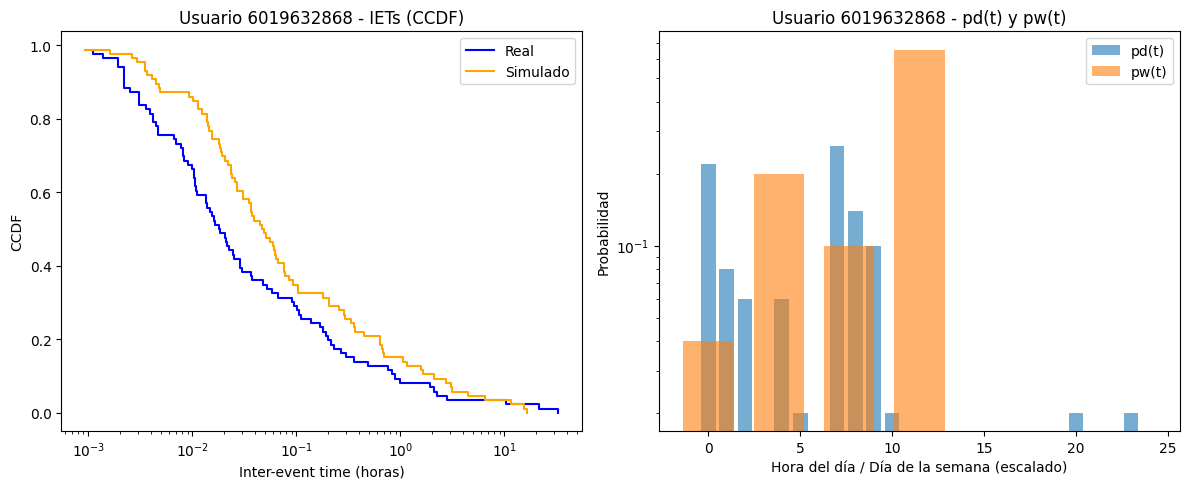

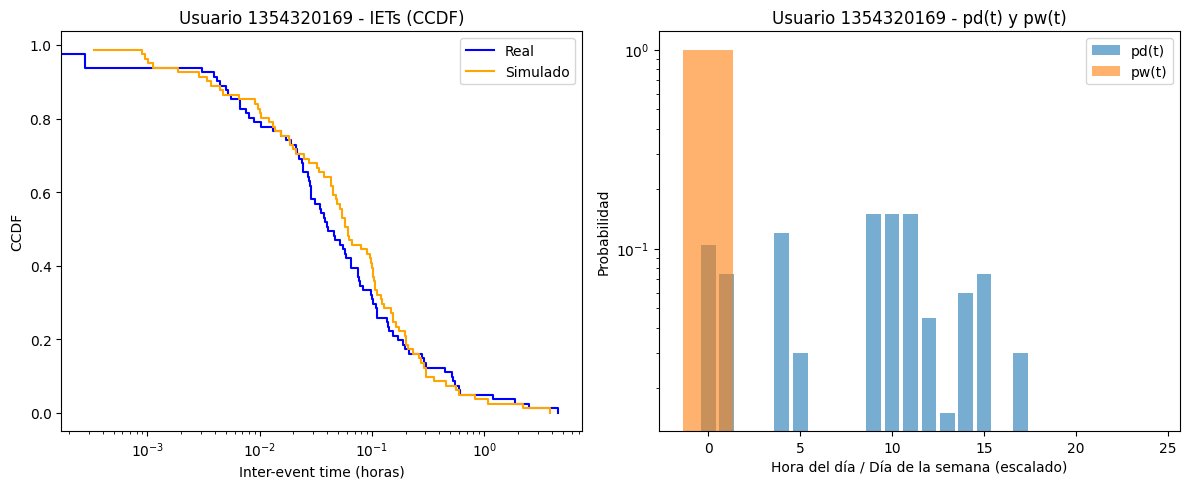

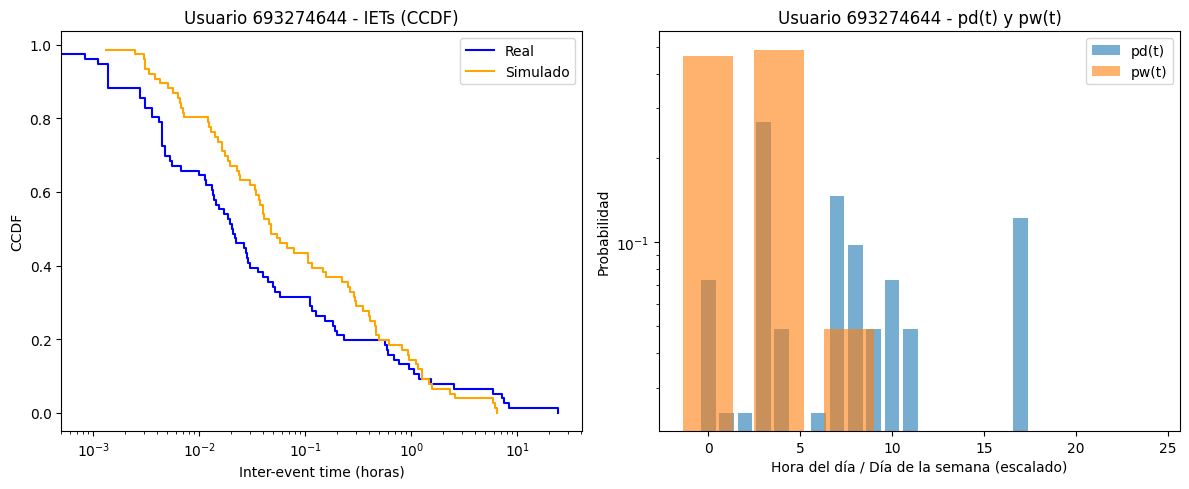

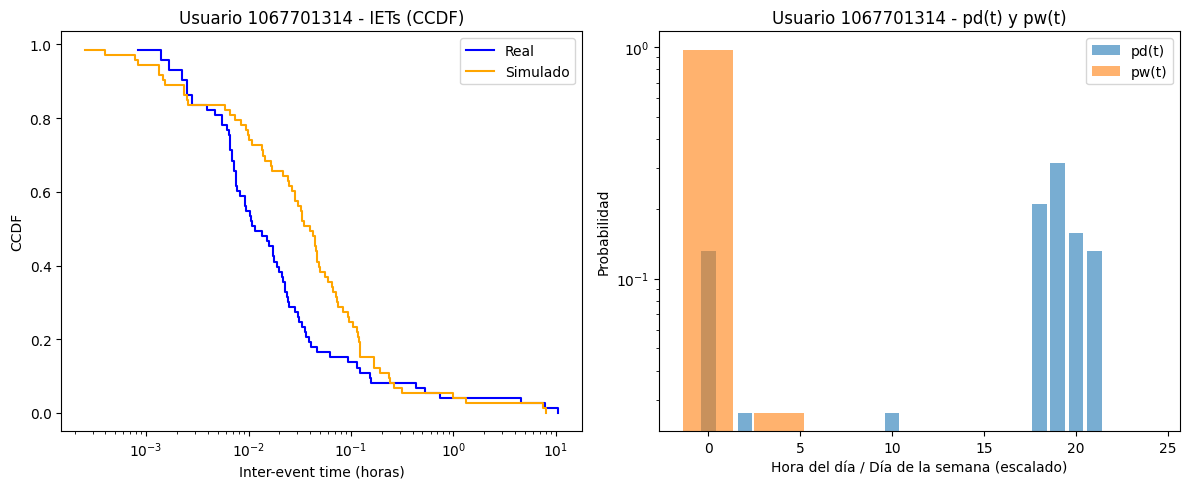

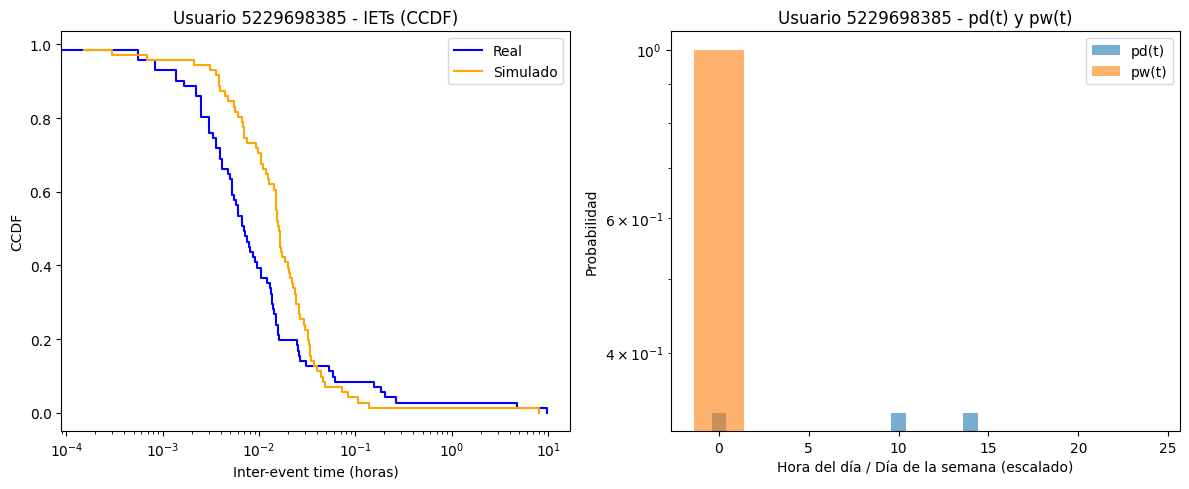

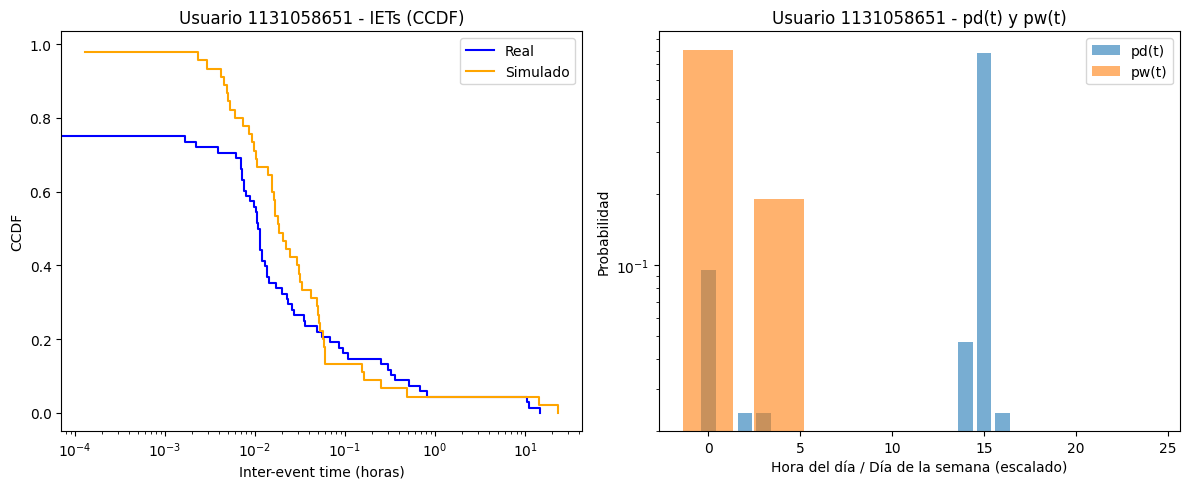

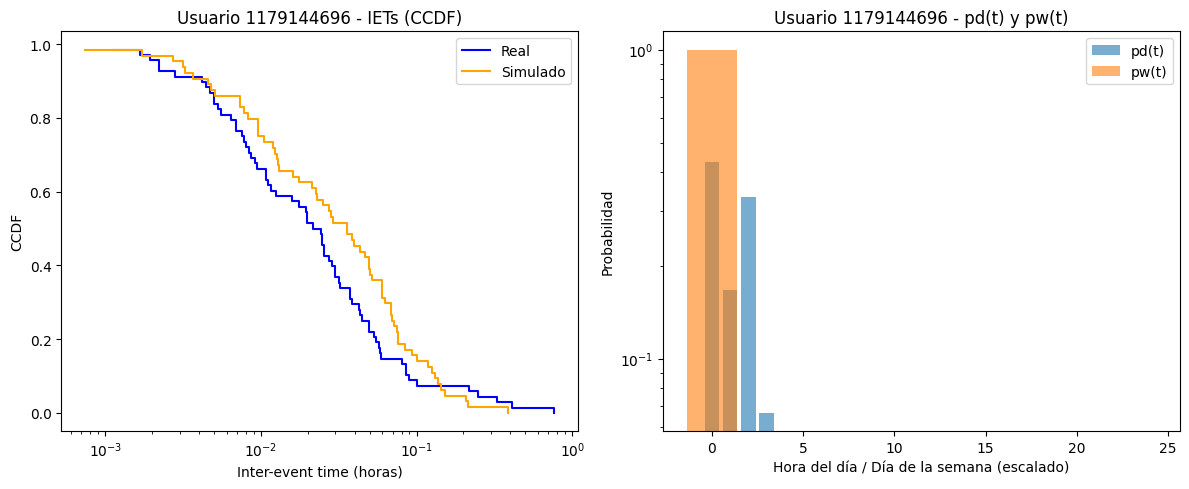

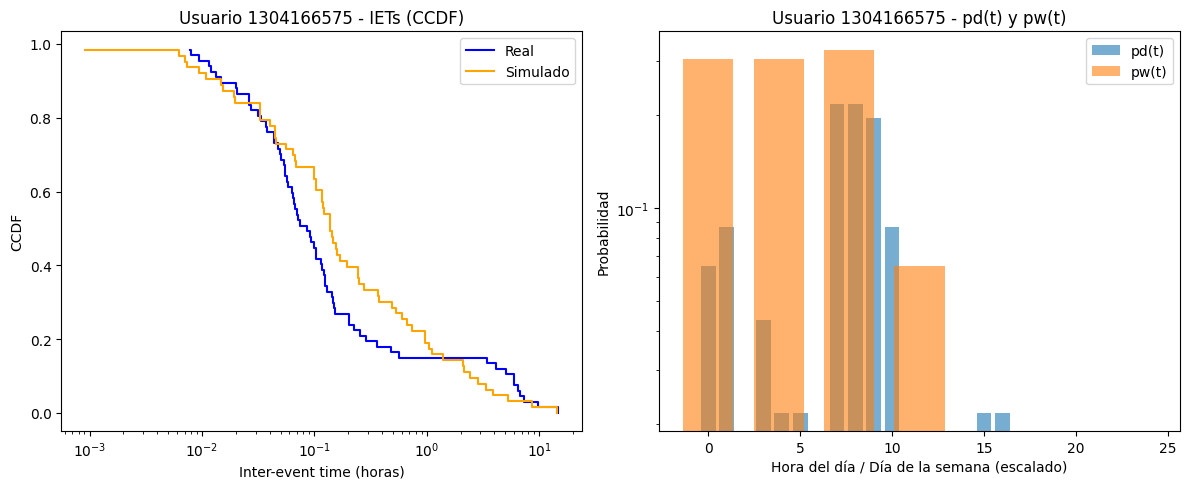

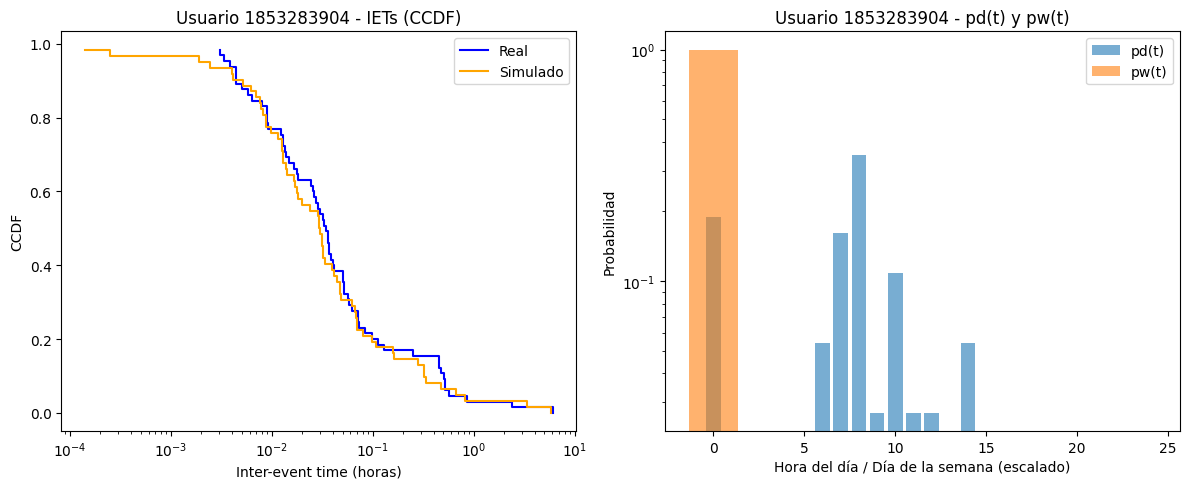

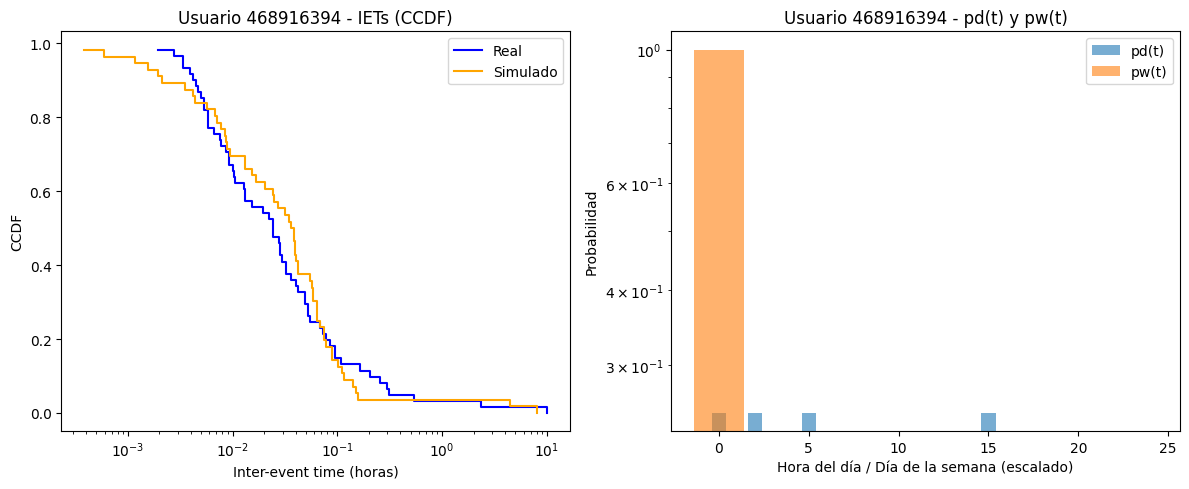

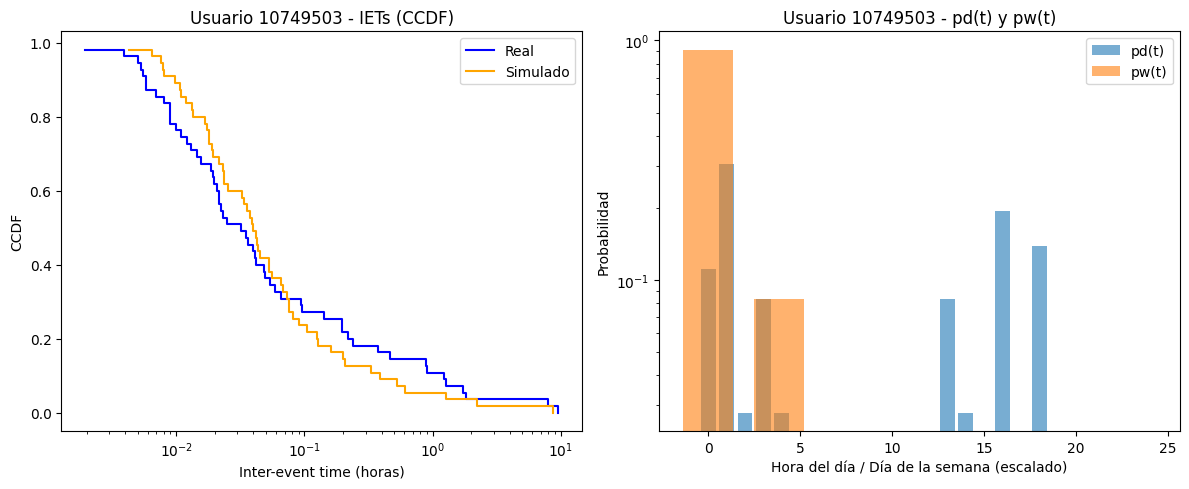

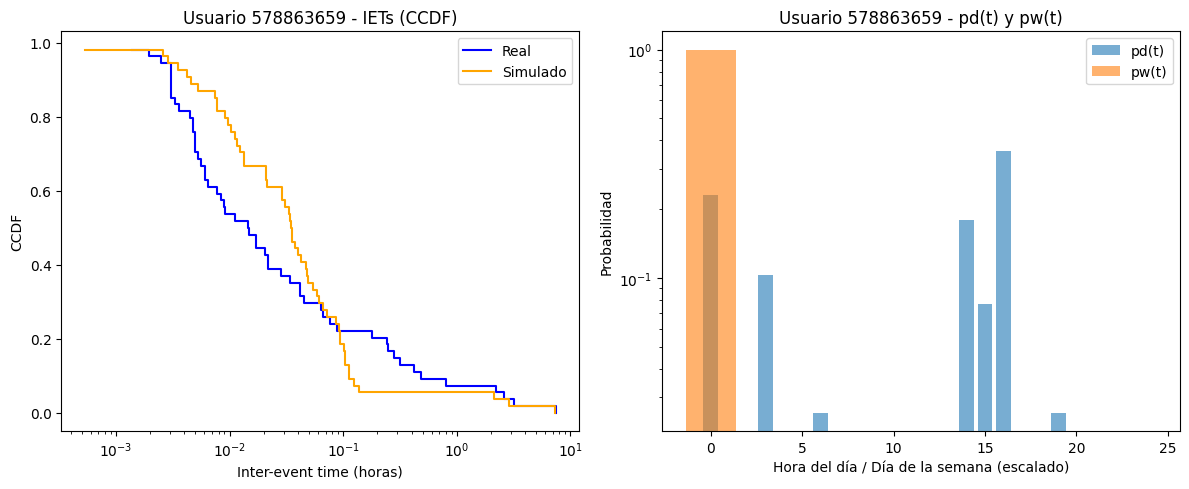

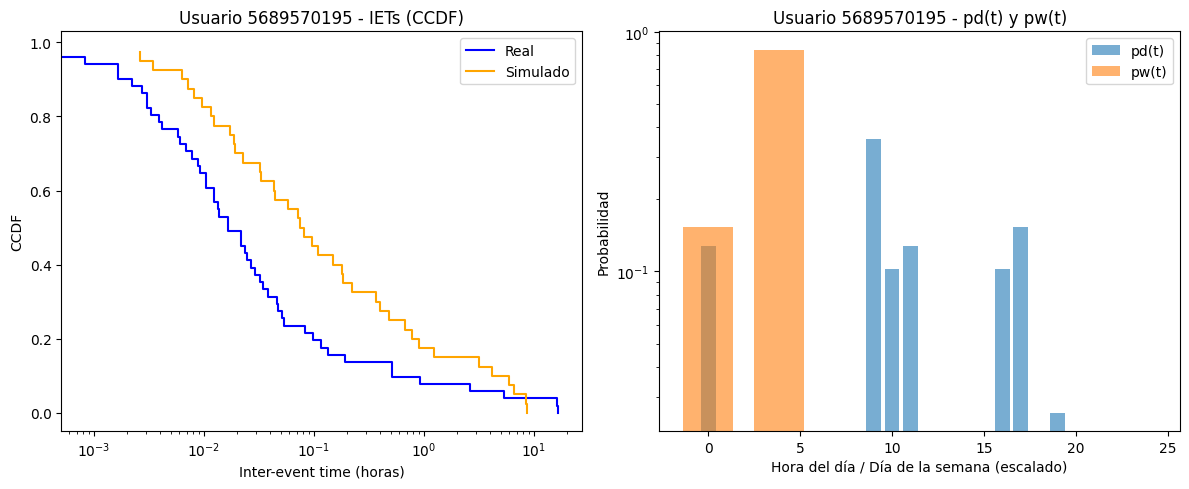

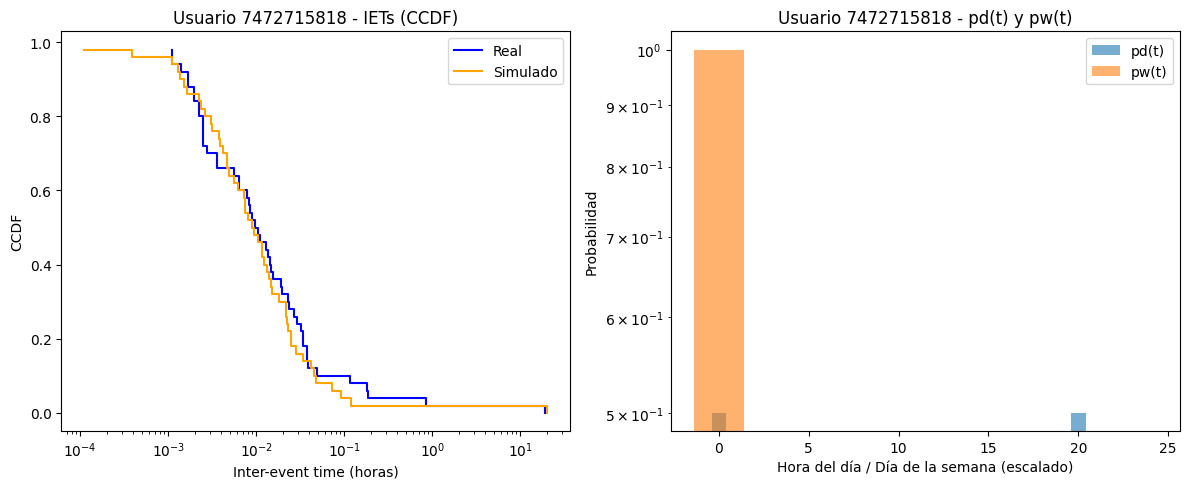

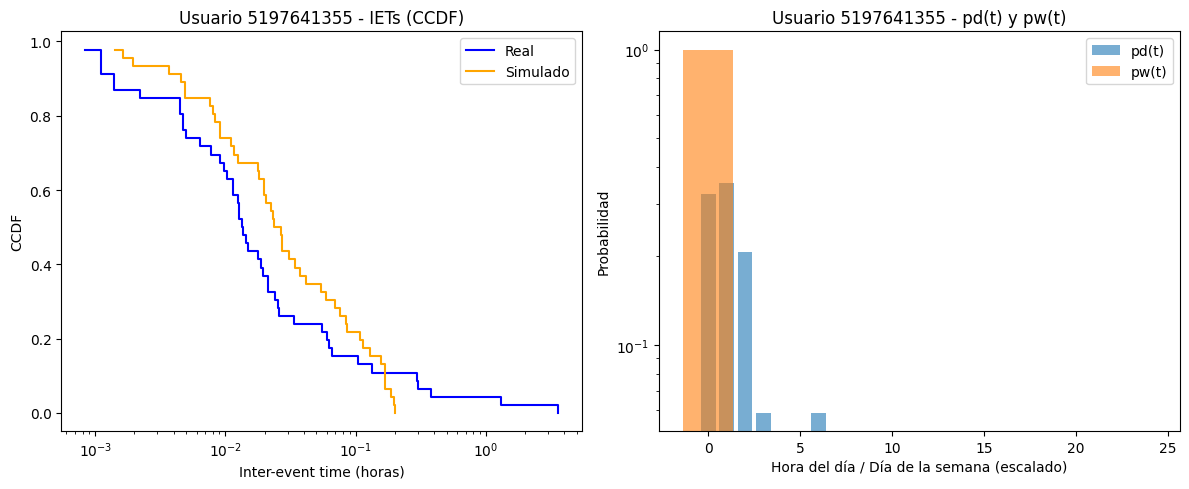

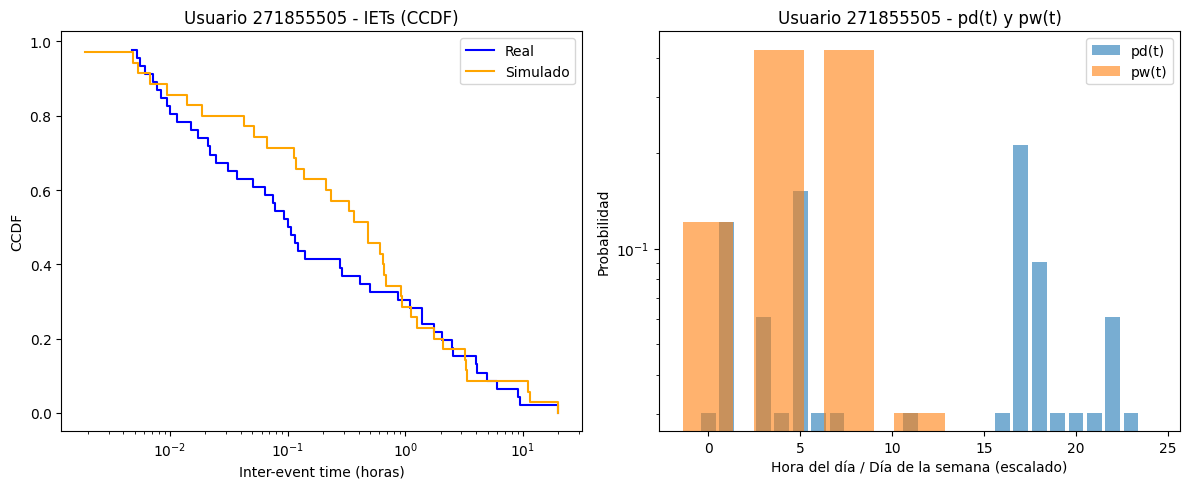

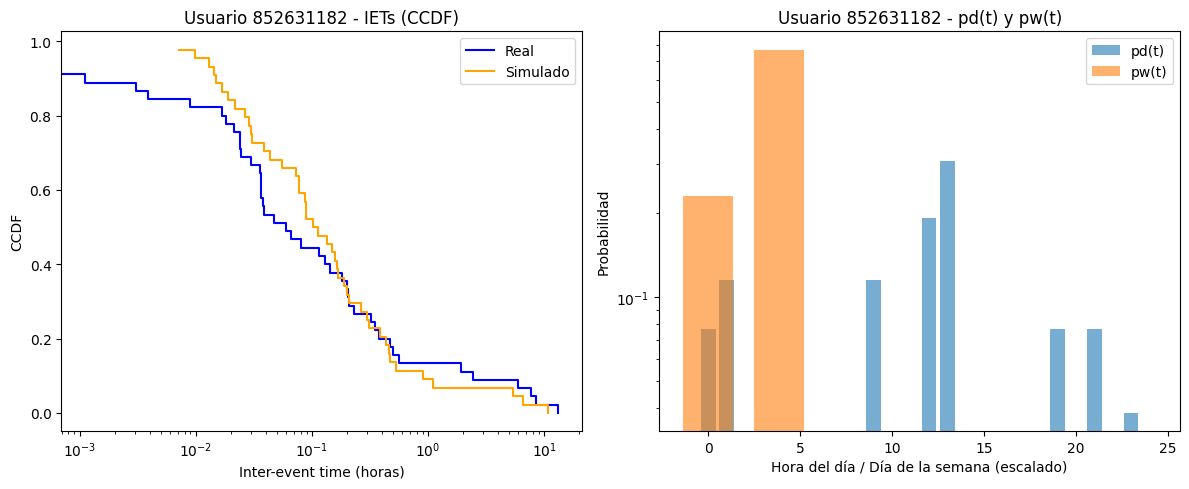

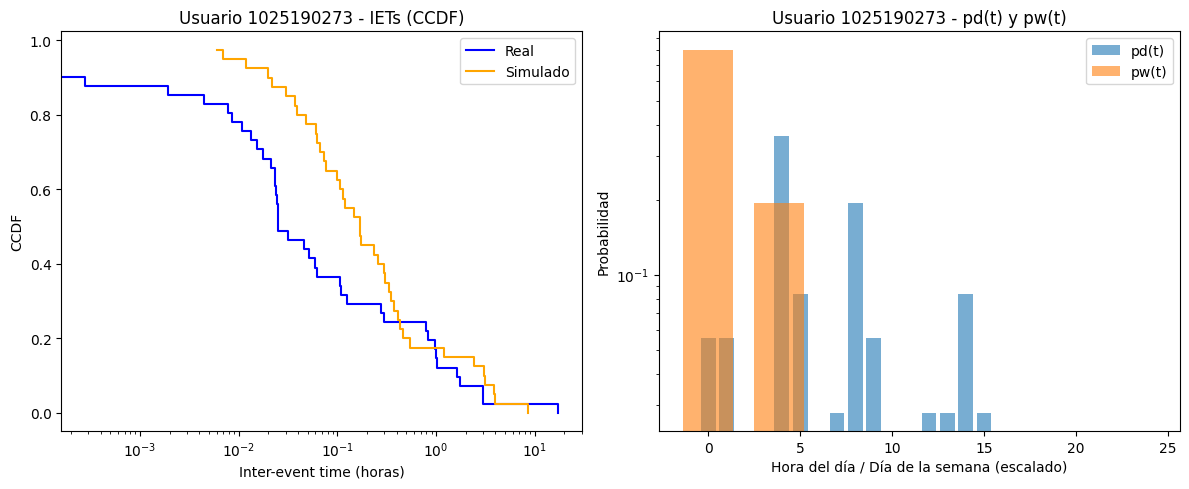

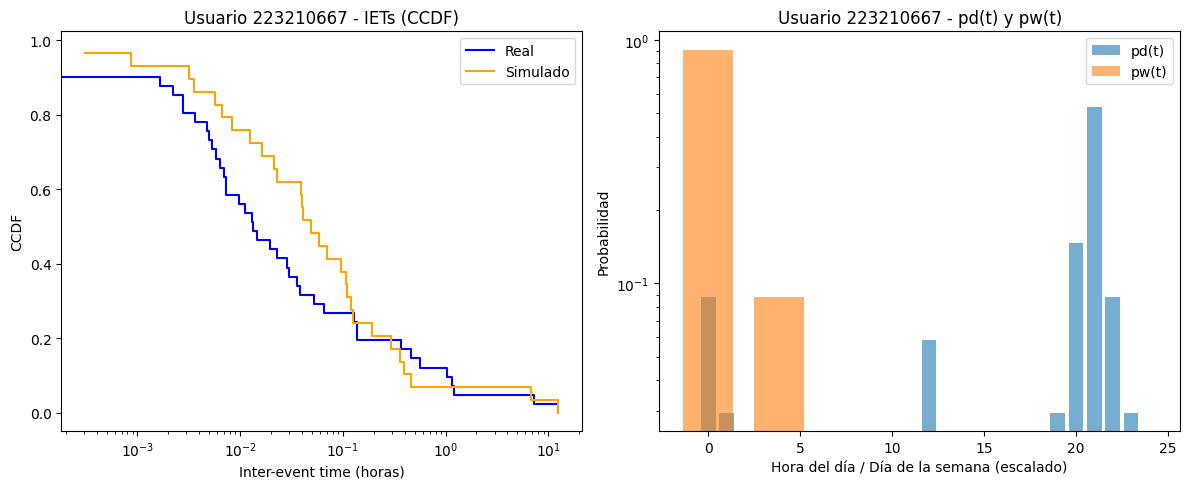

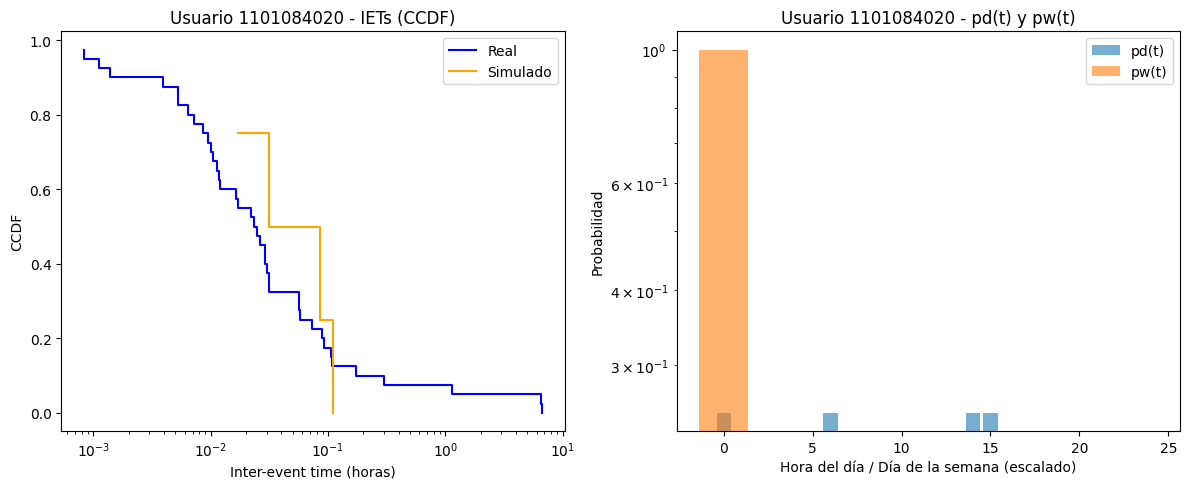

In [46]:
# Comparar IETs reales vs simulados para cada usuario y CCDFs una al lado de la otra
for user_id in active_users:
    user_events = df_first_week[df_first_week['sender_id'] == user_id]['date'].sort_values()
    if len(user_events) < 2:
        continue
    real_iets = np.diff((user_events - user_events.iloc[0]).dt.total_seconds() / 3600)
    sim_iets = np.diff(simulated_cascades[user_id])
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    # Dibujar CCDF empírica (1 - ECDF) usando step
    def plot_ccdf(data, **kwargs):
        if len(data) == 0:
            return
        x = np.sort(data)
        y = 1.0 - np.arange(1, len(x) + 1) / len(x)
        plt.step(x, y, where='post', **kwargs)
    plot_ccdf(real_iets, label='Real', color='blue')
    plot_ccdf(sim_iets, label='Simulado', color='orange')
    plt.xscale('log')
    plt.xlabel('Inter-event time (horas)')
    plt.ylabel('CCDF')
    plt.title(f'Usuario {user_id} - IETs (CCDF)')
    plt.legend()
    plt.subplot(1, 2, 2)
    # Mostrar pd(t) y pw(t); pw se dibuja sobre 7 posiciones distribuidas en 24h
    plt.bar(range(24), parameters_users[user_id]['pd_t'], alpha=0.6, label='pd(t)')
    pw_x = np.linspace(0, 23, 7)
    plt.bar(pw_x, parameters_users[user_id]['pw_t'], width=24/7*0.8, alpha=0.6, label='pw(t)')
    plt.xlabel('Hora del día / Día de la semana (escalado)')
    plt.ylabel('Probabilidad')
    plt.yscale('log')
    plt.title(f'Usuario {user_id} - pd(t) y pw(t)')
    plt.legend()
    plt.tight_layout()
    plt.show()

## Montecarlo Testing

In [47]:
def monte_carlo_pvalue(empirical_iet, model_params, M=100, sa_iter=5000):
    """
    Test de hipótesis Monte Carlo (Malmgren et al. 2008, Fig. S2).

    Procedimiento correcto:
      1. Calcular A = area(D, M(θ̂))  [datos empíricos vs modelo con parámetros estimados]
      2. Para s = 1..M:
           a. Generar Ds ~ M(θ̂)
           b. Re-ejecutar SA sobre Ds → θ̂s
           c. Generar Ms ~ M(θ̂s)
           d. As = area(Ds, Ms)
      3. p-valor (dos colas) = P(|As - ⟨As⟩| > |A - ⟨As⟩|)

    Args:
        empirical_iet : array de IETs empíricos (en horas)
        model_params  : tupla (rho_a, Nw, pd_t, pw_t, p_Na, total_hours)
        M             : número de réplicas sintéticas
        sa_iter       : iteraciones de SA por réplica
    """
    rho_a, Nw, pd_t, pw_t, p_Na, total_hours = model_params
    N = len(empirical_iet) + 1

    # Paso 1: A(D, M(θ̂))
    model_events = simulate_cascading_nhpp(rho_a, Nw, pd_t, pw_t, p_Na, total_hours, N)
    if len(model_events) < 2:
        return np.nan
    A_empirical = area_test_statistic(empirical_iet, np.diff(model_events))

    # Paso 2: bucle Monte Carlo — re-ajustar SA en cada réplica sintética
    A_synthetic = []
    for s in range(M):
        print(f"  Monte Carlo réplica {s+1}/{M}...")
        # (a) Generar Ds ~ M(θ̂)
        syn_events = simulate_cascading_nhpp(rho_a, Nw, pd_t, pw_t, p_Na, total_hours, N)
        if len(syn_events) < 4:
            continue

        # (b) Re-ejecutar SA sobre Ds → θ̂s
        syn_config, _ = simulated_annealing(syn_events, n_iter=sa_iter)
        rho_a_s, Nw_s, pd_t_s, pw_t_s = compute_model_params(
            syn_events, np.concatenate([[False], syn_config])
        )
        p_Na_s = get_pNa(syn_config)

        # (c) Generar Ms ~ M(θ̂s)
        model_syn_events = simulate_cascading_nhpp(
            rho_a_s, Nw_s, pd_t_s, pw_t_s, p_Na_s, total_hours, len(syn_events)
        )
        if len(model_syn_events) < 2:
            continue

        # (d) As = area(Ds, Ms)
        A_s = area_test_statistic(np.diff(syn_events), np.diff(model_syn_events))
        A_synthetic.append(A_s)

    if len(A_synthetic) == 0:
        return np.nan

    A_synthetic = np.array(A_synthetic)
    A_mean = np.mean(A_synthetic)

    # Paso 3: p-valor de dos colas
    p_value = np.mean(np.abs(A_synthetic - A_mean) > np.abs(A_empirical - A_mean))
    return p_value


In [ ]:
# Save info into csv for later analysis
results_df = pd.DataFrame({
    'user_id': list(parameters_users.keys()),
    'rho_a': [params['rho_a'] for params in parameters_users.values()],
    'pd_t': [params['pd_t'] for params in parameters_users.values()],
    'pw_t': [params['pw_t'] for params in parameters_users.values()],
    'p_Na': [params['p_Na'] for params in parameters_users.values()]
    'Nw': [params['Nw'] for params in parameters_users.values()],
    'A_best': [params['A_best'] for params in parameters_users.values()],

})
results_df.to_csv('circadian_cycles_first_week_results.csv', index=False)

In [50]:
# Calcular p-valores para cada usuario (M=20 para test; usar M=100, sa_iter=5000 para final)
pvalues_users = {}
i=0
for user_id in active_users:
    if user_id not in parameters_users:
        continue
    print(f"Calculando p-valor para usuario {user_id}... ({i+1}/{len(active_users)})")
    i += 1
    user_events = df_first_week[df_first_week['sender_id'] == user_id]['date'].sort_values()
    events_hours = (user_events - user_events.iloc[0]).dt.total_seconds() / 3600
    empirical_iets = np.diff(events_hours.values)

    params = parameters_users[user_id]
    model_params = (
        params['rho_a'], params['Nw'], params['pd_t'],
        params['pw_t'], params['p_Na'],           # p_Na estimada por SA, no hardcodeada
        events_hours.iloc[-1] - events_hours.iloc[0]
    )

    p_value = monte_carlo_pvalue(empirical_iets, model_params, M=20, sa_iter=2000)
    pvalues_users[user_id] = p_value
    print(f"Usuario {user_id} - P-valor: {p_value:.4f}")


Calculando p-valor para usuario 1095473116... (1/31)
  Monte Carlo réplica 1/20...
  Init: 94.9% pares mergeados  (threshold=0.4320h = 25.9min, candidatos=149/157)
  Monte Carlo réplica 2/20...
  Init: 82.0% pares mergeados  (threshold=0.3031h = 18.2min, candidatos=50/61)
  Monte Carlo réplica 3/20...
  Init: 90.2% pares mergeados  (threshold=0.2443h = 14.7min, candidatos=129/143)
  Monte Carlo réplica 4/20...
  Init: 48.0% pares mergeados  (threshold=0.0206h = 1.2min, candidatos=107/223)
  Monte Carlo réplica 5/20...
  Init: 96.4% pares mergeados  (threshold=0.7072h = 42.4min, candidatos=133/138)
  Monte Carlo réplica 6/20...
  Init: 96.0% pares mergeados  (threshold=0.3527h = 21.2min, candidatos=214/223)
  Monte Carlo réplica 7/20...
  Init: 94.5% pares mergeados  (threshold=0.3451h = 20.7min, candidatos=172/182)
  Monte Carlo réplica 8/20...
  Init: 87.2% pares mergeados  (threshold=0.1989h = 11.9min, candidatos=123/141)
  Monte Carlo réplica 9/20...
  Init: 91.2% pares mergeados  (

In [54]:
print("\nP-valores de usuarios activos:")
for user_id, p_value in pvalues_users.items():
    print(f"Usuario {user_id}: p-valor={p_value:.4f}")


P-valores de usuarios activos:
Usuario 1095473116: p-valor=0.2000
Usuario 1762777403: p-valor=0.0000
Usuario 1457424889: p-valor=0.2632
Usuario 7094531229: p-valor=0.0000
Usuario 702737014: p-valor=1.0000
Usuario 57072401: p-valor=0.1000
Usuario 1110241832: p-valor=0.0000
Usuario 5212333848: p-valor=0.0500
Usuario 1065332141: p-valor=0.1500
Usuario 5564321416: p-valor=0.0500
Usuario 6221273187: p-valor=0.9500
Usuario 6019632868: p-valor=0.9500
Usuario 1354320169: p-valor=0.2500
Usuario 693274644: p-valor=0.0500
Usuario 1067701314: p-valor=0.0000
Usuario 5229698385: p-valor=0.3889
Usuario 1131058651: p-valor=0.9000
Usuario 1179144696: p-valor=0.5000
Usuario 1304166575: p-valor=0.7000
Usuario 1853283904: p-valor=0.2000
Usuario 468916394: p-valor=1.0000
Usuario 10749503: p-valor=0.9500
Usuario 578863659: p-valor=0.1000
Usuario 5689570195: p-valor=0.0000
Usuario 7472715818: p-valor=0.6154
Usuario 5197641355: p-valor=0.6500
Usuario 271855505: p-valor=0.2500
Usuario 852631182: p-valor=0.850

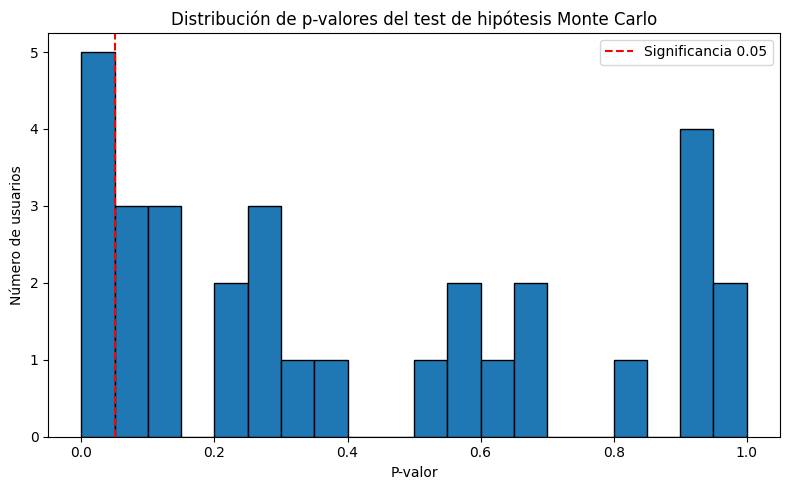

In [56]:
# plot p-valores
plt.figure(figsize=(8, 5))
plt.hist(list(pvalues_users.values()), bins=20, edgecolor='black')
plt.xlabel('P-valor')
plt.ylabel('Número de usuarios')
plt.title('Distribución de p-valores del test de hipótesis Monte Carlo')
plt.axvline(0.05, color='red', linestyle='--', label='Significancia 0.05')
plt.legend()
plt.tight_layout()
plt.show()

### Representación gráfica

In [51]:
def plot_log_residuals(empirical_iet, model_iet, title=''):
    """
    R = ln(p_model(τ) / p_empirical(τ))
    Si el modelo es bueno, R debe ser pequeño y sin estructura sistemática
    """
    log_bins = np.logspace(-2, 3, 50)  # en horas
    
    hist_emp, _ = np.histogram(empirical_iet, bins=log_bins, density=True)
    hist_mod, _ = np.histogram(model_iet, bins=log_bins, density=True)
    
    bin_centers = np.sqrt(log_bins[:-1] * log_bins[1:])
    
    # Evitar log(0)
    mask = (hist_emp > 0) & (hist_mod > 0)
    R = np.log(hist_mod[mask] / hist_emp[mask])
    
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.loglog(bin_centers[mask], hist_emp[mask], 'o', label='Datos SMS')
    plt.loglog(bin_centers[mask], hist_mod[mask], '-', label='Modelo CNHPP')
    plt.axvline(16, ls='--', color='gray', label='16h')
    plt.axvline(32, ls='--', color='gray', label='32h')
    plt.xlabel('Inter-event time (h)')
    plt.ylabel('PDF')
    plt.legend()
    plt.title(f'CCDF comparison {title}')
    
    plt.subplot(1, 2, 2)
    plt.semilogx(bin_centers[mask], R, 'o-')
    plt.axhline(0, color='k', ls='--')
    plt.axvspan(16, 32, alpha=0.2, color='red', label='Zona de interés')
    plt.xlabel('Inter-event time (h)')
    plt.ylabel('Log-residual R')
    plt.title('Si R≈0 en 16-32h → modelo captura el bump')
    plt.legend()
    plt.tight_layout()
    plt.show()

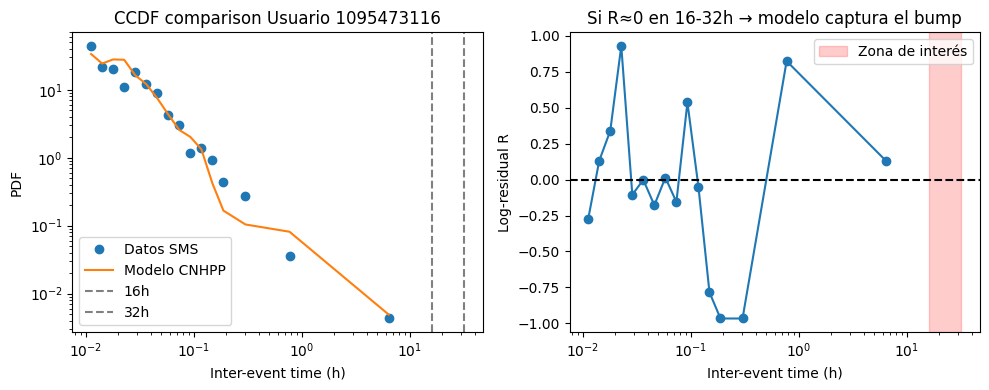

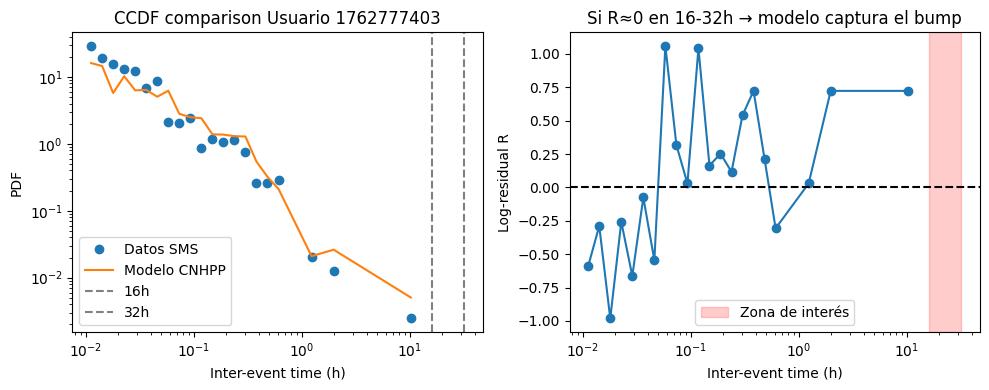

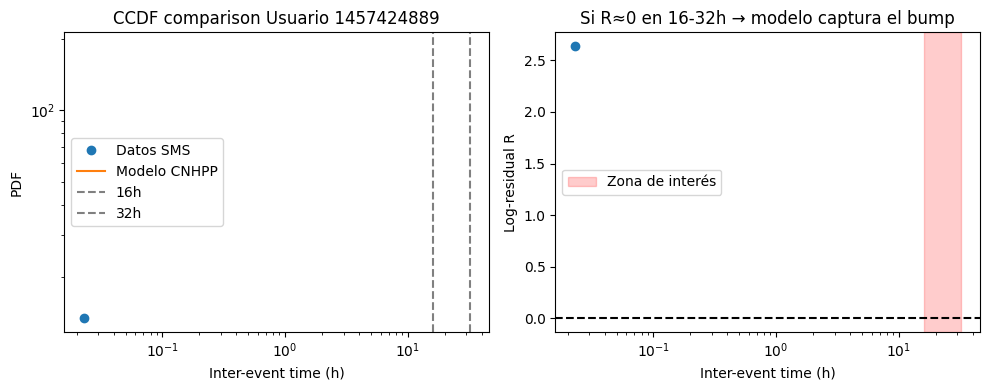

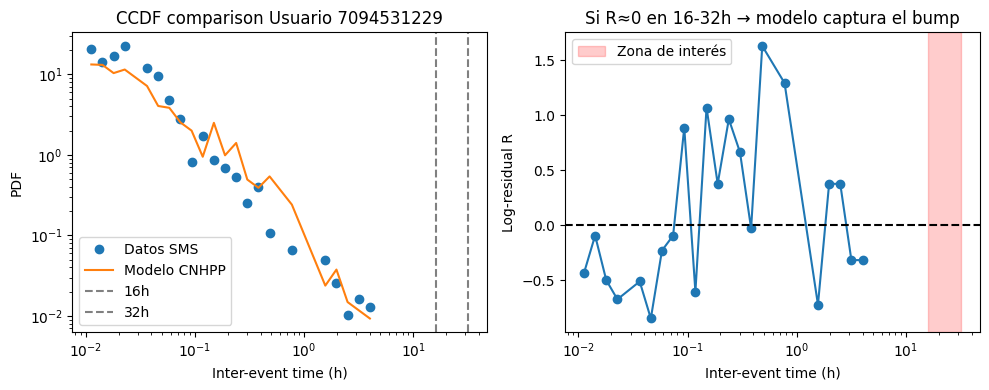

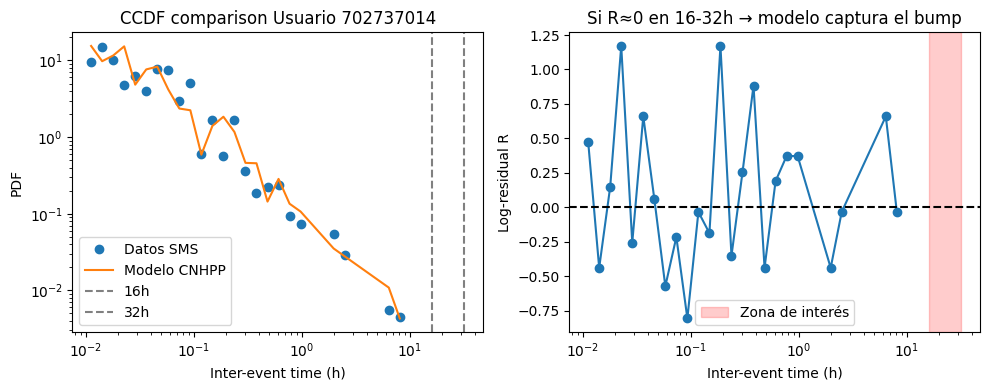

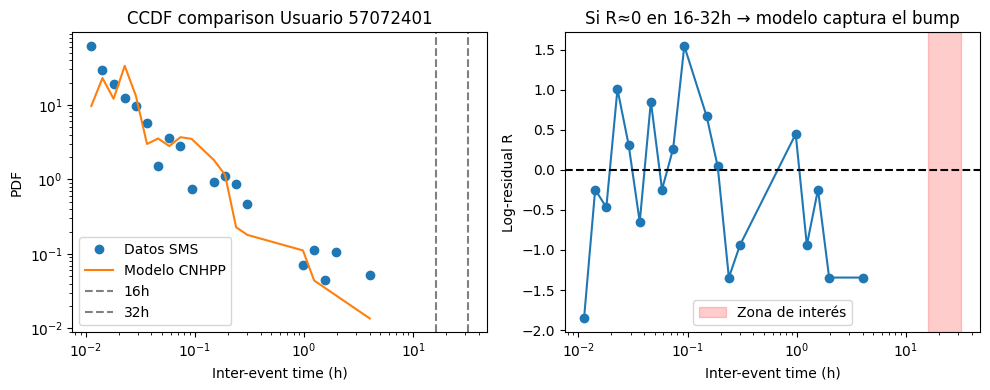

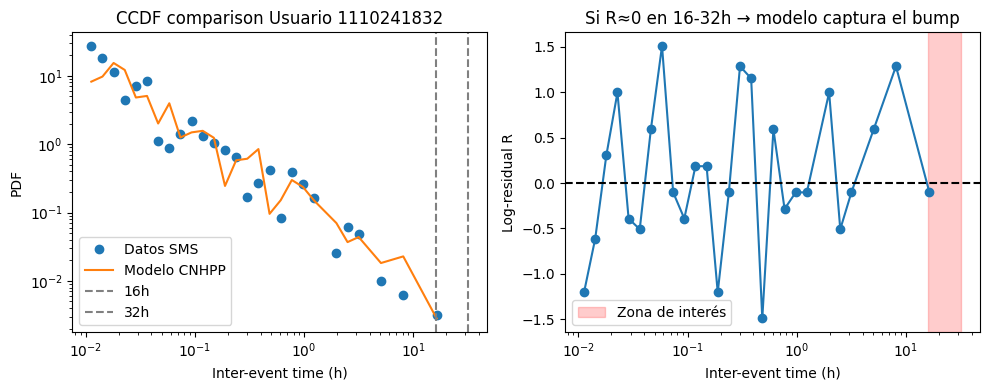

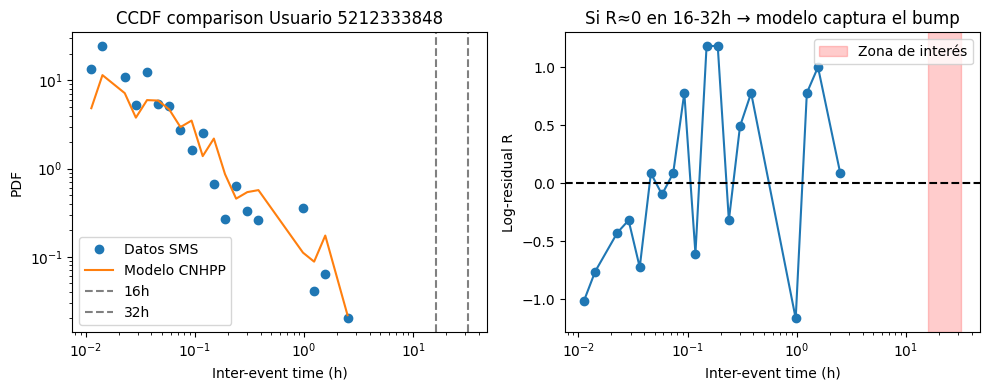

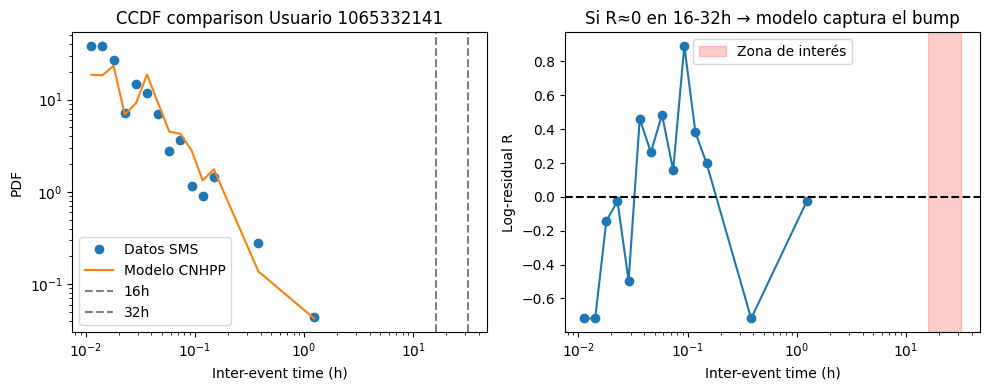

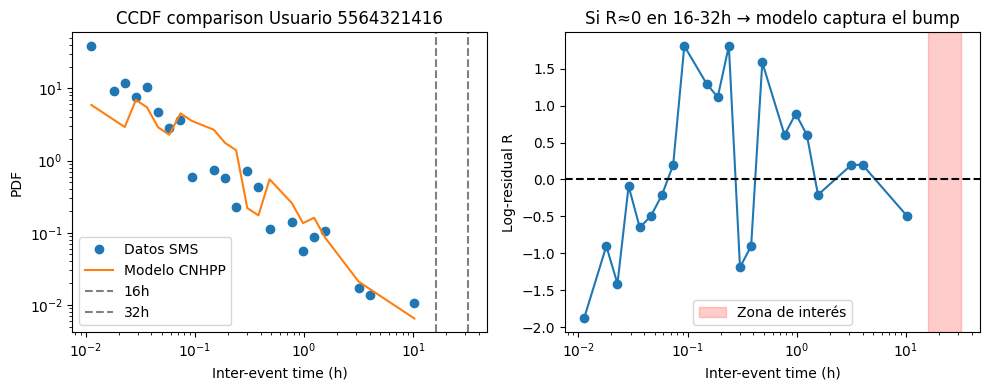

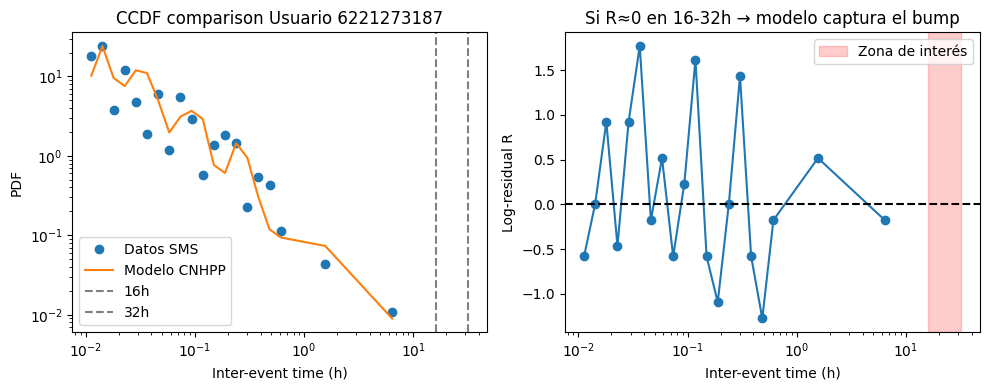

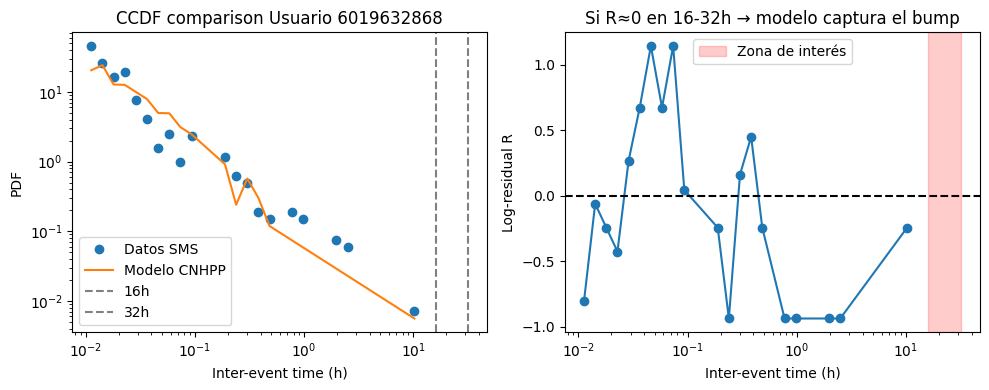

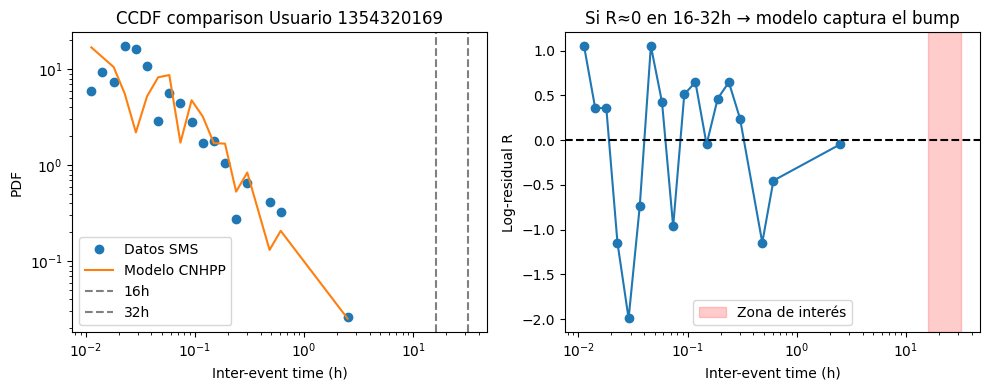

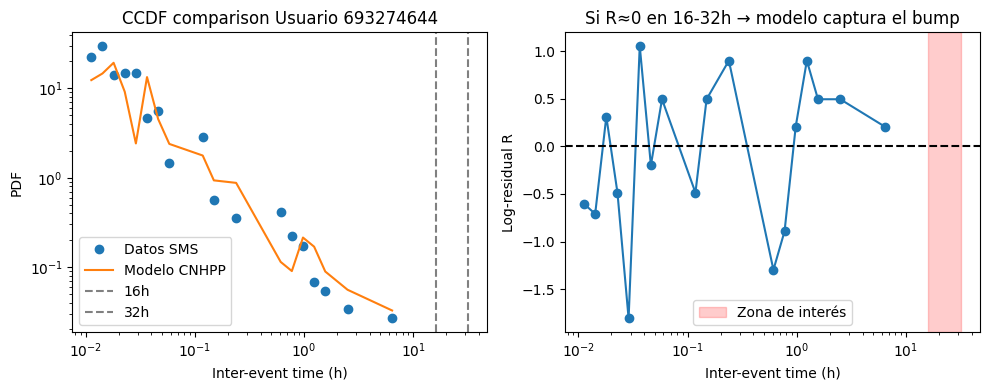

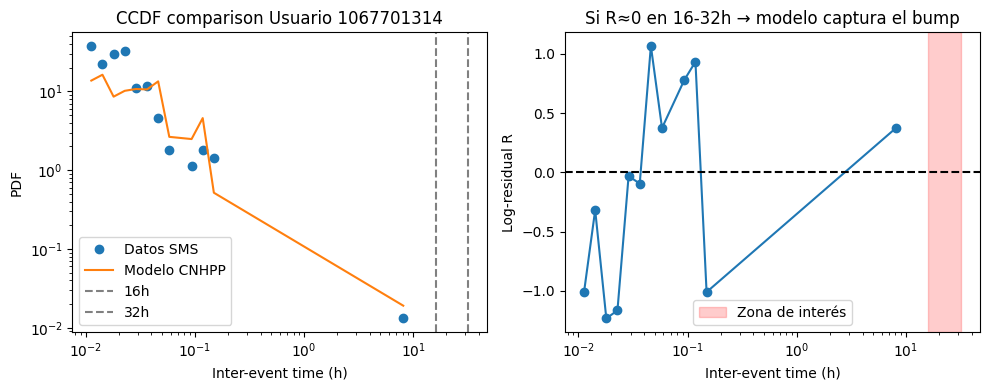

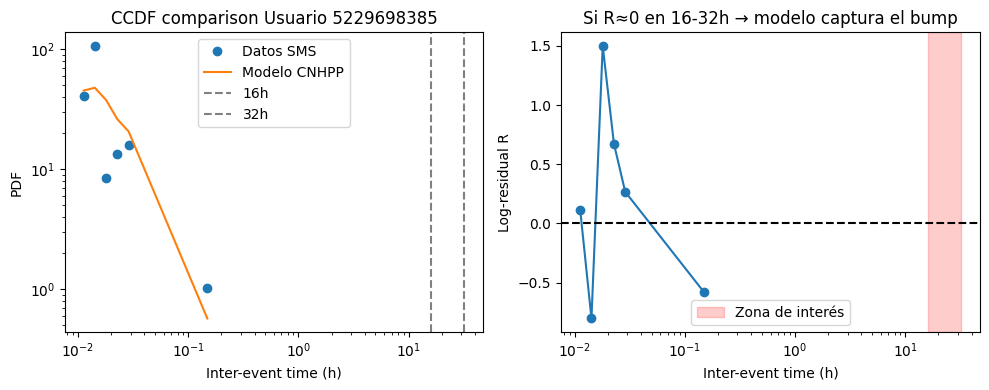

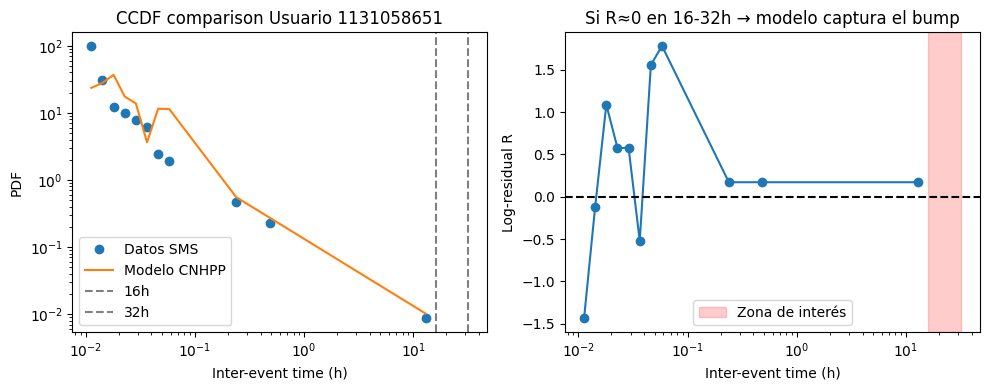

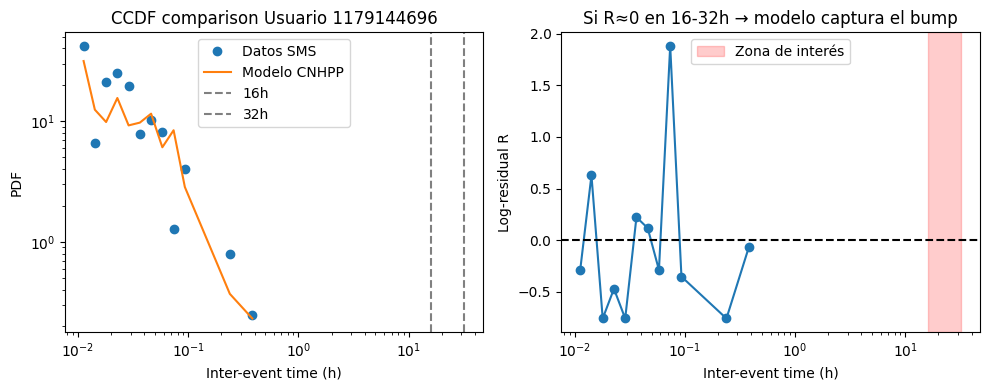

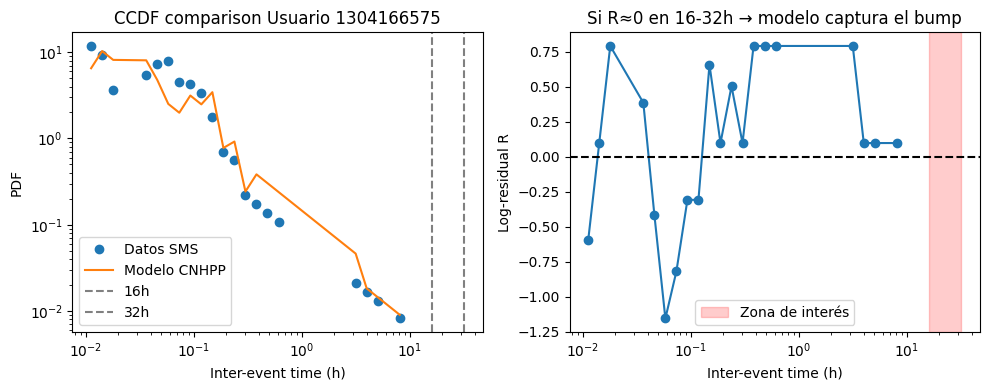

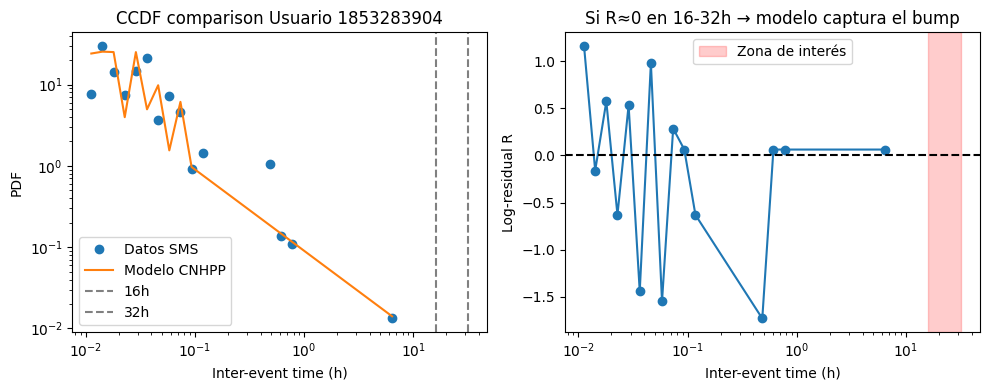

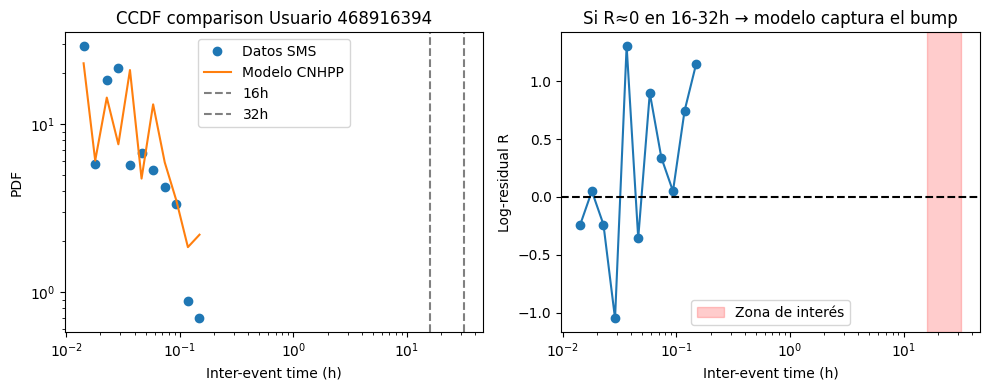

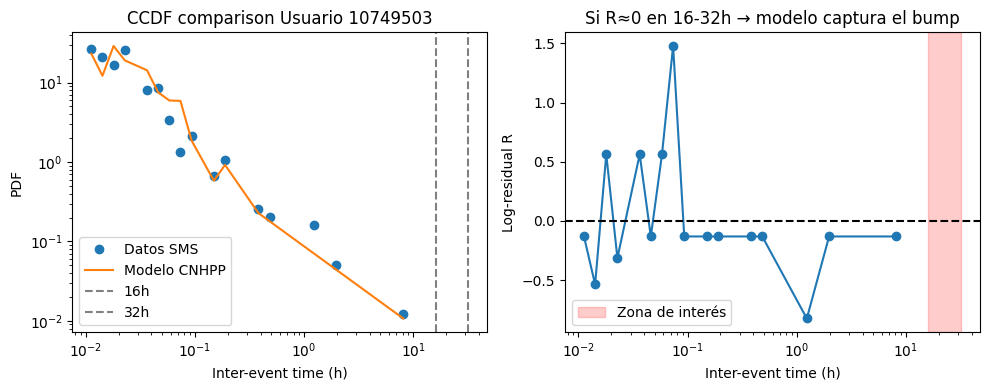

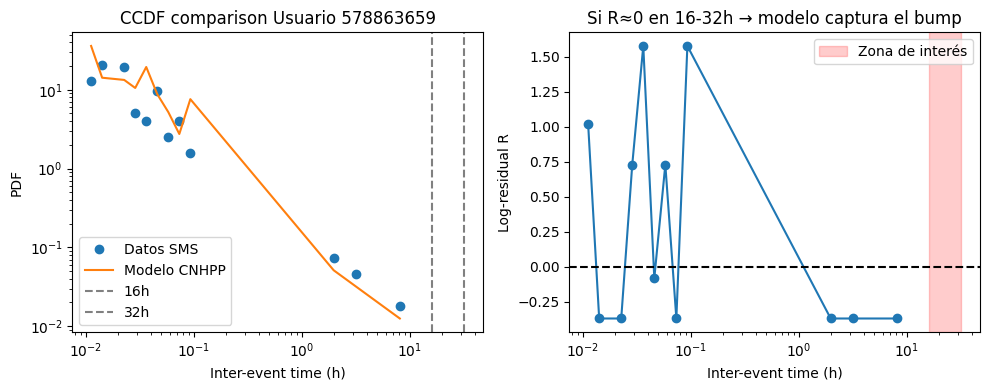

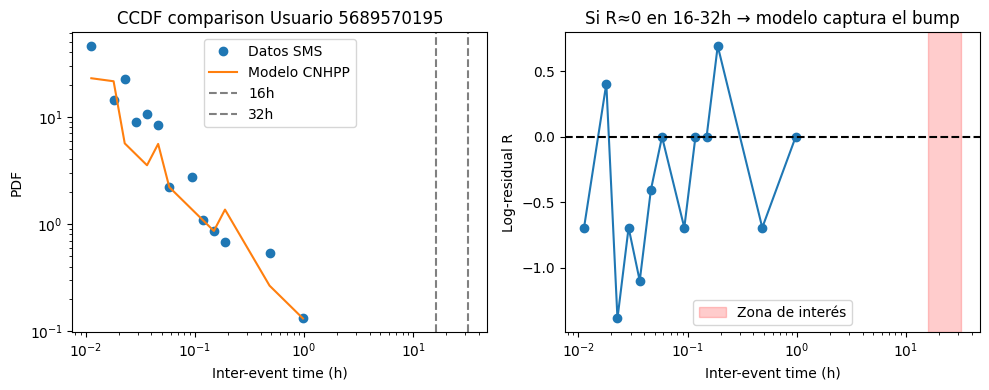

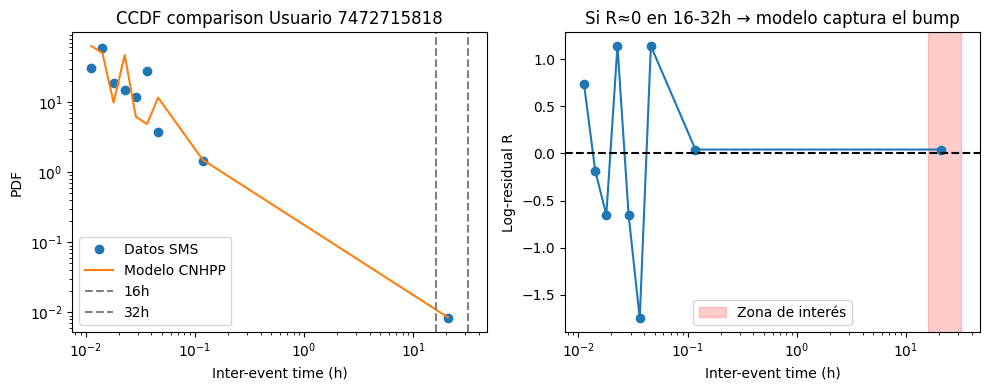

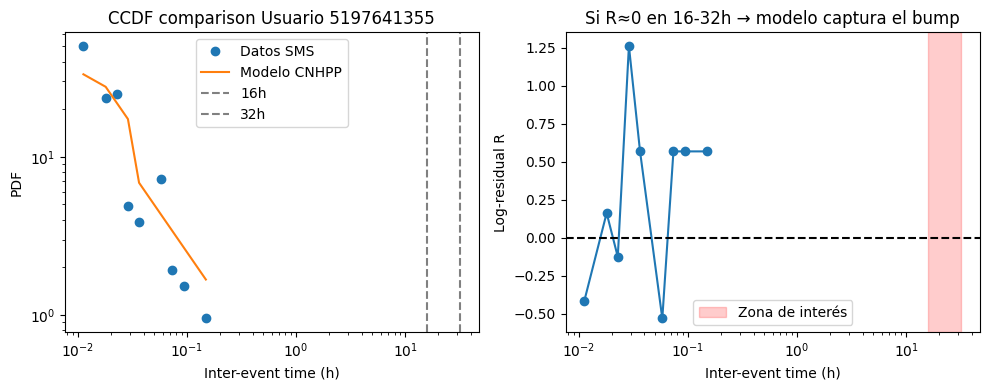

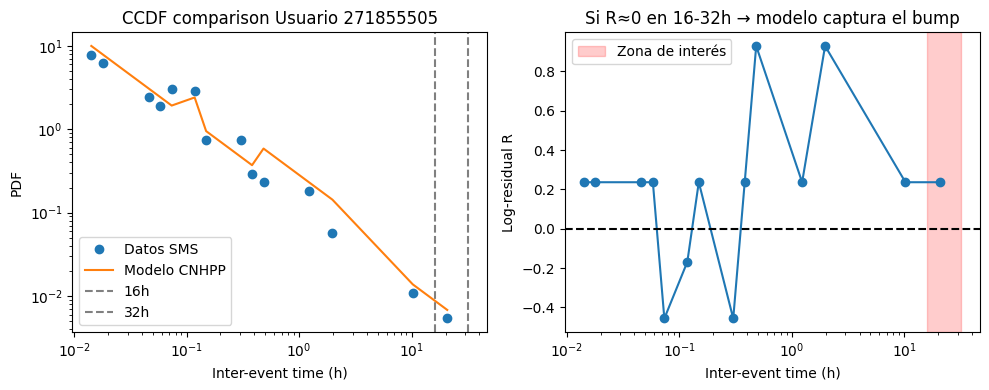

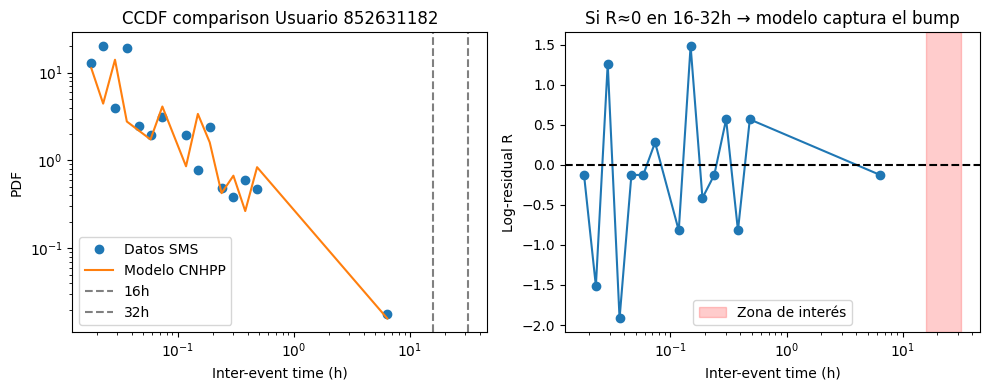

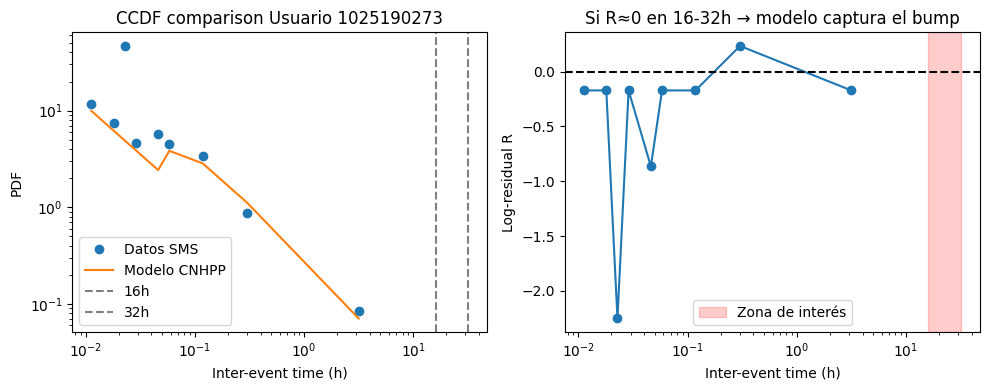

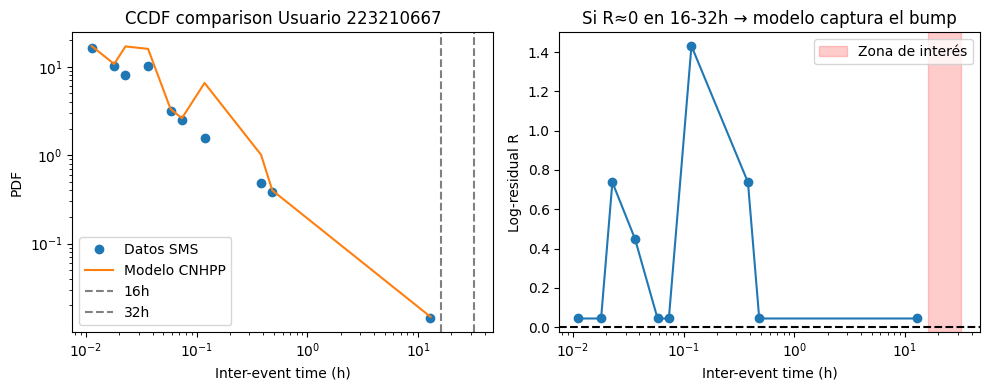

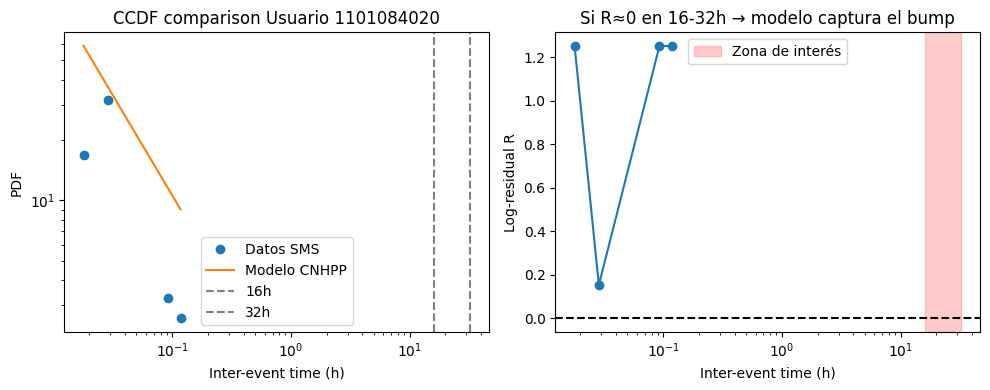

In [52]:
# Plot the log residuals for each user
for user_id in active_users:
    if user_id not in parameters_users:
        continue
    
    user_events = df_first_week[df_first_week['sender_id'] == user_id]['date'].sort_values()
    events_hours = (user_events - user_events.iloc[0]).dt.total_seconds() / 3600
    empirical_iets = np.diff(events_hours.values)
    
    sim_events = simulated_cascades[user_id]
    simulated_iets = np.diff(sim_events)
    
    plot_log_residuals(empirical_iets, simulated_iets, title=f'Usuario {user_id}')  

## Save info

In [55]:
# Save info into csv for later analysis
results_df = pd.DataFrame({
    'user_id': list(parameters_users.keys()),
    'rho_a': [params['rho_a'] for params in parameters_users.values()],
    'Nw': [params['Nw'] for params in parameters_users.values()],
    'pd_t': [params['pd_t'] for params in parameters_users.values()],
    'pw_t': [params['pw_t'] for params in parameters_users.values()],
    'p_Na': [params['p_Na'] for params in parameters_users.values()],
    'A_best': [params['A_best'] for params in parameters_users.values()],
    'p_value': [pvalues_users.get(user_id, np.nan) for user_id in parameters_users.keys()]
})
results_df.to_csv('circadian_cycles_first_week_results.csv', index=False)